In [1]:
import pyodbc
import pandas as pd
import warnings
warnings.filterwarnings('ignore')
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline
import numpy as np

In [2]:
conn=pyodbc.connect("Driver={SQL Server};"
                    "Server=.\SQLEXPRESS;"
                    "Database=Bank_Analysis;"
                    "Trusted_conn=yes;")

In [3]:
connection=conn.cursor()

In [4]:
client_df=pd.read_sql("Select * from client",conn)
account_df=pd.read_sql("select * from account",conn)
disposition_df=pd.read_sql("Select * from disp",conn)
district_df=pd.read_sql("Select * from district",conn)
order_df=pd.read_sql("Select * from [order]",conn)
card_df=pd.read_sql("Select * from [card]",conn)
loan_df=pd.read_sql("Select * from loan",conn)
transaction_df=pd.read_sql("select * from master_transaction",conn)

In [6]:
client_account_df=pd.merge(left=account_df,right=pd.merge(left=client_df,right=disposition_df,left_on='client_id',right_on='client_id',how='left'),left_on='account_id',right_on='account_id',how='left')

In [7]:
client_account_df['date']=pd.to_datetime(client_account_df['date'])

In [8]:
client_account_df.head(2)

,account_id,district_id_x,frequency,date,Account_type,card_assigned,client_id,birth_number,district_id_y,sex,birth_date,age,disp_id,type
0,1,18,Monthly Issuance,2020-03-24,NRI account,Silver,1,706213,18,Female,1970-12-13,None,1,OWNER
1,2,1,Monthly Issuance,2018-02-26,Salary account,Silver,2,450204,1,Male,1945-02-04,None,2,OWNER


In [9]:
result=client_account_df.groupby(client_account_df['date'].dt.year)['client_id'].count().reset_index(name='count')

In [10]:
result=result.rename(columns={'date':'year'})

In [11]:
result

,year,count
0,2018,1385
1,2019,513
2,2020,768
3,2021,1624
4,2022,1079


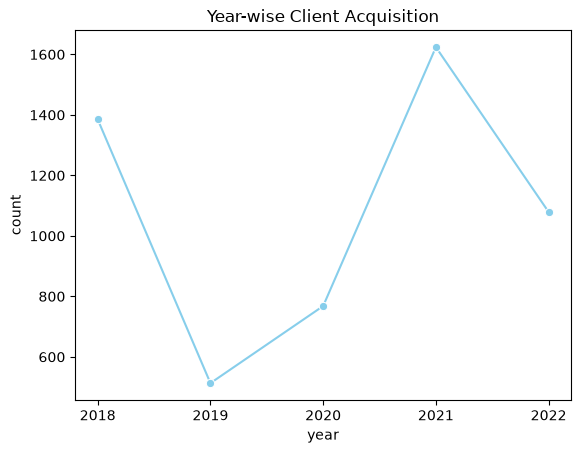

In [12]:
sns.lineplot(data=result,x='year',y='count',color='skyblue',marker='o')
plt.title('Year-wise Client Acquisition')
plt.xticks(result['year'].astype(int))
plt.show()

In [13]:
client_account_df['birth_date']=pd.to_datetime(client_account_df['birth_date'])

In [14]:
# Convert dates to datetime
client_account_df['birth_date'] = pd.to_datetime(client_account_df['birth_date'])
client_account_df['date'] = pd.to_datetime(client_account_df['date'])

# Calculate age at account opening
client_account_df['age'] = (
    client_account_df['date'].dt.year 
    - client_account_df['birth_date'].dt.year
    - (
        (client_account_df['date'].dt.month < client_account_df['birth_date'].dt.month)
        |
        (
            (client_account_df['date'].dt.month == client_account_df['birth_date'].dt.month)
            &
            (client_account_df['date'].dt.day < client_account_df['birth_date'].dt.day)
        )
    ).astype(int)
)

In [15]:
bins = [18, 25, 60, 100]
labels = ['18-25', '26-60', '60+']

client_account_df['age_group'] = pd.cut(
    client_account_df['age'],
    bins=bins,
    labels=labels)
   

In [16]:
age_distribution=client_account_df.groupby('age_group')['client_id'].count().reset_index(name='count')

In [17]:
age_distribution

,age_group,count
0,26-60,2203
1,60+,3060


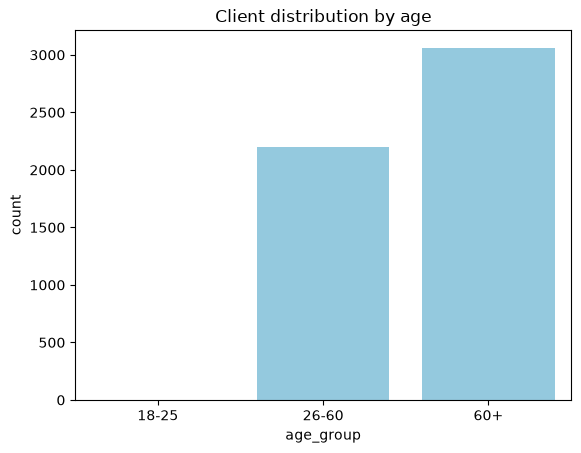

In [18]:
sns.barplot(data=age_distribution,x='age_group',y='count',color='skyblue')
plt.title('Client distribution by age')
plt.show()

In [19]:
sex_distribution=client_account_df.groupby('sex')['client_id'].count().reset_index(name='count')

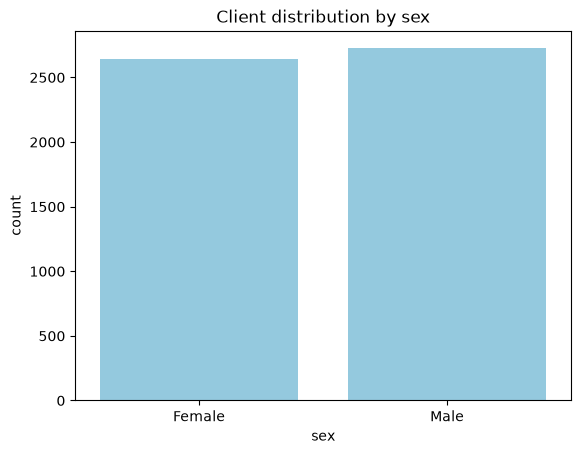

In [20]:
sns.barplot(data=sex_distribution,x='sex',y='count',color='skyblue')
plt.title('Client distribution by sex')
plt.show()

In [21]:
client_district=pd.merge(left=client_df, right=district_df, left_on='district_id' , right_on='district_id',how='left')

In [22]:
client_region=client_district.groupby('region')['client_id'].count().reset_index(name='count').sort_values(by='count',ascending=False)

In [23]:
client_region

,region,count
6,south Moravia,937
4,north Moravia,920
1,central Bohemia,664
0,Prague,663
2,east Bohemia,660
3,north Bohemia,561
7,west Bohemia,515
5,south Bohemia,449


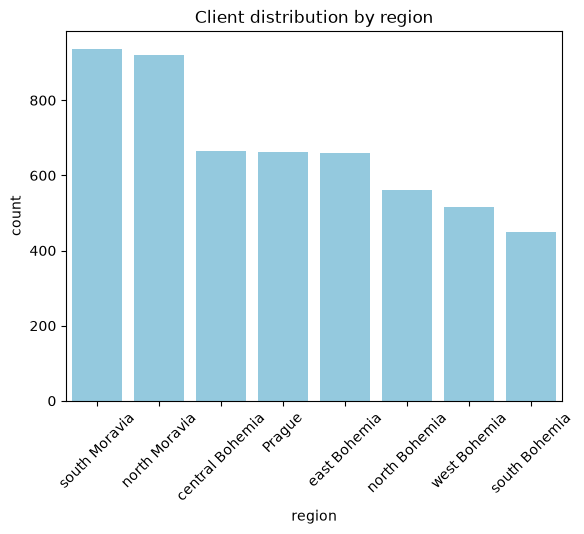

In [24]:
sns.barplot(data=client_region,x='region',y='count',color='skyblue')
plt.title('Client distribution by region')
plt.xticks(rotation=45)
plt.show()

In [25]:
client_district1=client_district.groupby(['district_name','region'])['client_id'].count().reset_index(name='count').sort_values(by='count',ascending=False)

In [26]:
client_district1

,district_name,region,count
17,Hl.m. Praha,Prague,663
43,Ostrava - mesto,north Moravia,180
26,Karvina,north Moravia,169
4,Brno - mesto,south Moravia,155
75,Zlin,south Moravia,109
...,...,...,...
23,Jihlava,south Moravia,44
76,Znojmo,south Moravia,44
54,Pribram,central Bohemia,44
25,Karlovy Vary,west Bohemia,43


In [27]:
user_owner=client_account_df.groupby('type')['client_id'].count().reset_index(name='count')

,type,count
0,OWNER,4500
1,USER,869


In [ ]:
sns.barplot(data=owner_user,x='type',y='count',color='skyblue')
plt.title('Client distribution by type')
plt.xticks(rotation=45)
plt.show()

- 83.8% of clients are Account Owners, meaning most clients directly own and manage their accounts.
- 16.2% are Authorised Users, indicating a smaller segment of users who access accounts without being the primary owner.

In [28]:
account_count=client_account_df.groupby('client_id')['account_id'].count().reset_index(name='account_count')

In [29]:
client_order_df=pd.merge(left=client_account_df,right=order_df,left_on='account_id',right_on='account_id',how='left')

In [30]:
order_count=client_order_df.groupby('client_id')['order_id'].count().reset_index(name='order_count')

In [31]:
client_loan_df=pd.merge(left=client_account_df,right=loan_df,left_on='account_id',right_on='account_id')

In [32]:
loan_count=client_loan_df.groupby('client_id')['loan_id'].count().reset_index(name='loan_count')

In [33]:
client_card_df=pd.merge(left=client_account_df,right=card_df,left_on='disp_id',right_on='disp_id',how='left')

In [34]:
card_count=client_card_df.groupby('client_id')['card_id'].count().reset_index(name='card_count')

In [35]:
client_account_df=client_account_df.merge(account_count,on='client_id',how='left')
client_account_df=client_account_df.merge(order_count,on='client_id',how='left')
client_account_df=client_account_df.merge(loan_count,on='client_id',how='left')
client_account_df=client_account_df.merge(card_count,on='client_id',how='left')

In [36]:
client_account_df

,account_id,district_id_x,frequency,date,Account_type,card_assigned,client_id,birth_number,district_id_y,sex,birth_date,age,disp_id,type,age_group,account_count,order_count,loan_count,card_count
0,1,18,Monthly Issuance,2020-03-24,NRI account,Silver,1,706213,18,Female,1970-12-13,49,1,OWNER,26-60,1,1,NaN,0
1,2,1,Monthly Issuance,2018-02-26,Salary account,Silver,2,450204,1,Male,1945-02-04,73,2,OWNER,60+,1,2,1.0,0
2,2,1,Monthly Issuance,2018-02-26,Salary account,Silver,3,406009,1,Female,1940-10-09,77,3,USER,60+,1,2,1.0,0
3,3,5,Monthly Issuance,2022-07-07,NRI account,Silver,4,561201,5,Male,1956-12-01,65,4,OWNER,60+,1,3,NaN,0
4,3,5,Monthly Issuance,2022-07-07,NRI account,Silver,5,605703,5,Female,1960-07-03,62,5,USER,60+,1,3,NaN,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5364,11349,1,Weekly Issuanace,2020-05-26,NRI account,Diamond,13955,456030,1,Female,1945-10-30,74,13647,OWNER,60+,1,2,1.0,0
5365,11349,1,Weekly Issuanace,2020-05-26,NRI account,Diamond,13956,430406,1,Male,1943-04-06,77,13648,USER,60+,1,2,1.0,0
5366,11359,61,Monthly Issuance,2019-10-01,NRI account,Silver,13968,680413,61,Male,1968-04-13,51,13660,OWNER,26-60,1,3,1.0,1
5367,11362,67,Monthly Issuance,2020-10-14,NRI account,Silver,13971,626019,67,Female,1962-10-19,57,13663,OWNER,26-60,1,5,1.0,0


In [37]:
client_account_df.account_count

0       1
1       1
2       1
3       1
4       1
       ..
5364    1
5365    1
5366    1
5367    1
5368    1
Name: account_count, Length: 5369, dtype: int64

In [38]:
count_cols = ['account_count', 'loan_count', 'order_count', 'card_count']
client_account_df[count_cols] = client_account_df[count_cols].fillna(0)

In [39]:
client_account_df['total_products'] = (client_account_df['account_count'] +client_account_df['loan_count'] +client_account_df['order_count'] +client_account_df['card_count'])

In [40]:
avg_products_per_client = client_account_df['total_products'].mean()
round(avg_products_per_client,0)

np.float64(3.0)

In [41]:
## in average client hold 3 products

In [42]:
client_account_df['date'] = pd.to_datetime(client_account_df['date'])

In [43]:
reference_date = pd.Timestamp('2022-12-31')

In [44]:
client_account_df['tenure_years'] = ((reference_date - client_account_df['date']).dt.days / 365.25)

In [45]:
client_account_df['tenure_years'] = client_account_df['tenure_years'].round(1)

In [46]:
round(client_account_df['tenure_years'].mean(),0)

np.float64(2.0)

In [47]:
# average tenure is 2 years

In [48]:
client_district_df=pd.merge(left=district_df,right=client_account_df,left_on='district_id',right_on='district_id_y',how='left')

In [49]:
district_lower=client_district_df.groupby('district_name')['client_id'].count().reset_index(name='total_client')

In [50]:
client_district_df=pd.merge(left=district_lower,right=client_district_df,left_on='district_name',right_on='district_name',how='left')

In [51]:
client_district_df.columns

Index(['district_name', 'total_client', 'district_id', 'region', 'population',
       'municipality_statistics1', 'municipality_statistics2',
       'municipality_statistics3', 'municipality_statistics4',
       'number_of_cities', 'urban_population_ratio', 'average_salary',
       'unemployment_rates2', 'entrepreneurs_per_1000_resident',
       'crime_statistics2', 'account_id', 'district_id_x', 'frequency', 'date',
       'Account_type', 'card_assigned', 'client_id', 'birth_number',
       'district_id_y', 'sex', 'birth_date', 'age', 'disp_id', 'type',
       'age_group', 'account_count', 'order_count', 'loan_count', 'card_count',
       'total_products', 'tenure_years'],
      dtype='str')

In [52]:
dist=client_district_df.groupby('district_name')['total_products'].sum().reset_index(name='dist_wise_prod')

In [53]:
client_district_df=pd.merge(left=dist,right=client_district_df,left_on='district_name',right_on='district_name',how='left')

In [54]:
district_adoption = client_district_df.groupby('district_name').agg(
    total_clients=('client_id', 'count'),
    total_products=('total_products', 'sum')).reset_index()

In [55]:
district_adoption['product_adoption'] = round(
    district_adoption['total_products'] /
    district_adoption['total_clients'],0
)

In [56]:
district_adoption = district_adoption.sort_values(
    by='product_adoption',
    ascending=True
)

In [57]:

six_districts = ['Rychnov nad Kneznou', 'Chrudim', 'Teplice', 'Hradec Kralove', 'Praha - vychod','Rokycany']

six_district_data1 = client_district_df[
    client_district_df['district_name'].isin(six_districts)
]

six_district_data1[['district_name','average_salary','unemployment_rates2']]

,district_name,average_salary,unemployment_rates2
744,Chrudim,8254,3.76
745,Chrudim,8254,3.76
746,Chrudim,8254,3.76
747,Chrudim,8254,3.76
748,Chrudim,8254,3.76
...,...,...,...
4747,Teplice,9317,7.07
4748,Teplice,9317,7.07
4749,Teplice,9317,7.07
4750,Teplice,9317,7.07


In [58]:
client_district_df['average_salary'].min()

np.int64(8110)

In [59]:
six_district_data = district_df[
    district_df['district_name'].isin(six_districts)
]

six_district_data

,district_id,district_name,region,population,municipality_statistics1,municipality_statistics2,municipality_statistics3,municipality_statistics4,number_of_cities,urban_population_ratio,average_salary,unemployment_rates2,entrepreneurs_per_1000_resident,crime_statistics2
9,10,Praha - vychod,central Bohemia,92084,55,29,4,3,5,46.700001,10124,0.54,141,4316
28,29,Rokycany,west Bohemia,45714,52,10,5,1,6,55.599998,8843,3.60,113,888
39,40,Teplice,north Bohemia,128118,9,16,6,3,8,85.300003,9317,7.07,97,6872
42,43,Hradec Kralove,east Bohemia,161854,73,21,6,1,6,76.300003,9425,2.50,125,3891
43,44,Chrudim,east Bohemia,105606,77,26,7,2,7,53.000000,8254,3.76,97,2325
47,48,Rychnov nad Kneznou,east Bohemia,78955,50,24,8,1,9,59.000000,9060,2.44,124,1717


Insights Summary (District-wise Lower Product Adoption):
Overall, selected low-adoption districts show around 2 products per client on average, indicating limited usage of multiple banking products.
Teplice:
Highest unemployment rate (7.07%) among selected districts.
Higher unemployment may reduce customers' ability or willingness to adopt additional products like loans and credit services.
Chrudim:
Lowest average salary (8254) among selected districts.
Lower income levels may limit demand for additional banking products.
Rokycany & Rychnov nad Kneznou:
Smaller population size and moderate urbanization may contribute to lower product penetration.
Customer base size and accessibility could impact adoption levels.
Praha - vychod:
Strong economic indicators (highest salary 10124, lowest unemployment 0.54%).
Lower adoption may not be due to economic factors; customer behaviour and cross-selling opportunities should be explored.
Hradec Kralove:
Good salary and urbanization levels.
Lower adoption likely requires product-level analysis to identify which products have lower penetration.

In [60]:
card_disp = card_df.merge(
    disposition_df,
    on='disp_id',
    how='inner'
)

In [61]:
client_card = card_disp.merge(
    client_account_df[['client_id','sex','age_group']],
    on='client_id',
    how='left'
)

In [62]:
card_owners = client_card.groupby(
    ['sex','age_group']
)['client_id'].nunique().reset_index(name='card_owners')

In [63]:
total_clients = client_account_df.groupby(
    ['sex','age_group']
)['client_id'].nunique().reset_index(name='total_clients')

In [64]:
card_analysis = total_clients.merge(
    card_owners,
    on=['sex','age_group'],
    how='left'
)

card_analysis['card_ownership_rate'] = (
    card_analysis['card_owners'] /
    card_analysis['total_clients'] * 100
)

In [65]:
card_analysis

,sex,age_group,total_clients,card_owners,card_ownership_rate
0,Female,26-60,1105,228,20.633484
1,Female,60+,1490,195,13.087248
2,Male,26-60,1098,230,20.947177
3,Male,60+,1570,237,15.095541


In [66]:
client_account_df.groupby(['sex','age_group']).agg(
    total_clients=('client_id','nunique'),
    total_accounts=('account_id'
,'nunique'))

total_clients  total_accounts
sex    age_group                               
Female 26-60               1105            1105
       60+                 1490            1490
Male   26-60               1098            1098
       60+                 1570            1570

In [67]:
client_card.groupby(['sex','age_group'])['client_id'].nunique().reset_index()

,sex,age_group,client_id
0,Female,26-60,228
1,Female,60+,195
2,Male,26-60,230
3,Male,60+,237


In [68]:
client_account_df.groupby(['sex','age_group'])['client_id'].nunique().reset_index()


,sex,age_group,client_id
0,Female,26-60,1105
1,Female,60+,1490
2,Male,26-60,1098
3,Male,60+,1570


Insights:
Highest card usage: Male 26-60 (230 card users, 20.95% ownership)
Lowest card usage: Female 60+ (195 card users, 13.09% ownership)
60+ customers mein card adoption lower hai compared to 26-60 segment.
Female 60+ segment mein total clients sabse zyada hain (1490), lekin card users proportionally kam hain, indicating lower card penetration.
Since all segments have similar account ownership (100%), low card adoption account availability ki wajah se nahi hai; ye mainly additional product adoption/customer behaviour se related ho sakta hai.
Possible reasons:
Older customers may prefer cash/traditional banking methods over card usage.
Younger/middle-aged customers are more likely to use cards for regular transactions.
Female 60+ segment mein digital/card adoption comparatively lower ho sakta hai.
Tumhare data se sabse strong conclusion ye banega:
Age appears to be a stronger factor than gender in card adoption, with 26-60 customers showing higher card ownership than 60+ customers.

In [69]:
client_account_df['product_segment'] = np.where(
    client_account_df['total_products'] == 1,
    'Single Product',
    'Multi Product'
)

In [70]:
client_account_df['product_segment'].value_counts()

product_segment
Multi Product     4750
Single Product     619
Name: count, dtype: int64

In [71]:
round(client_account_df.groupby('product_segment')['total_products'].mean(),0)

product_segment
Multi Product     3.0
Single Product    1.0
Name: total_products, dtype: float64

In [72]:
client_account_df.groupby('product_segment').agg(
    avg_accounts=('account_count','mean'),
    avg_cards=('card_count','mean'),
    avg_loans=('loan_count','mean'),
    avg_orders=('order_count','mean')
).round(2)

,avg_accounts,avg_cards,avg_loans,avg_orders
product_segment,,,,
Multi Product,1.0,0.19,0.17,1.66
Single Product,1.0,0.00,0.00,0.00


In [73]:
client_account_df.groupby('product_segment').agg(
    total_clients=('client_id','count'),
    avg_cards=('card_count','mean'),
    avg_loans=('loan_count','mean'),
    avg_orders=('order_count','mean'),
    avg_tenure=('tenure_years','mean'),
).round(2)

,total_clients,avg_cards,avg_loans,avg_orders,avg_tenure
product_segment,,,,,
Multi Product,4750,0.19,0.17,1.66,2.40
Single Product,619,0.00,0.00,0.00,2.44


The key behavioural difference is product engagement rather than tenure. Multi-product clients actively use multiple banking services, whereas single-product clients remain basic account holders, making them a suitable target for cross-selling campaigns.

In [74]:
account_category = client_account_df.groupby('account_id')['type'].agg(list).reset_index()
account_category['account_category'] = account_category['type'].apply(lambda x: 'Owner + User' if 'USER' in x else 'Owner Only')

In [75]:
client_account_df = client_account_df.merge(account_category[['account_id', 'account_category']],on='account_id',how='left')

In [76]:
owner_clients = client_account_df[
    client_account_df['type'] == 'OWNER'
]

In [77]:
owner_clients.groupby('account_category').agg(
    total_clients=('client_id', 'nunique'),
    avg_products=('total_products', 'mean'),
    avg_cards=('card_count', 'mean'),
    avg_loans=('loan_count', 'mean'),
    avg_orders=('order_count', 'mean'),
    avg_tenure=('tenure_years', 'mean')
).round(2)

,total_clients,avg_products,avg_cards,avg_loans,avg_orders,avg_tenure
account_category,,,,,,
Owner + User,869,2.95,0.17,0.17,1.61,2.44
Owner Only,3631,2.75,0.20,0.15,1.40,2.39


Clients with an Authorised User are more engaged overall.
Average products: 2.95 vs 2.75 for Owner Only clients.
Average orders: 1.61 vs 1.40, indicating more frequent use of banking services.
Loan adoption is slightly higher among Owner + User accounts (0.17 vs 0.15), suggesting greater use of credit products.
Card ownership is almost similar, with Owner Only clients showing a slightly higher average (0.20 vs 0.17). This difference is small and does not indicate a major behavioural gap.
Average tenure is nearly the same (2.44 vs 2.39 years), so the higher engagement of Owner + User accounts is not explained by longer customer relationships.

In [78]:
client_account_df=client_account_df.merge(district_df[['district_id','district_name','urban_population_ratio']],left_on='district_id_x',right_on='district_id',how='left')

In [79]:
district_product = client_account_df.groupby('district_name').agg(
    total_clients=('client_id','nunique'),
    avg_products=('total_products','mean'),
    avg_cards=('card_count','mean'),
    avg_loans=('loan_count','mean'),
    avg_orders=('order_count','mean')
).reset_index()

In [80]:
district_product = district_product.merge(
    district_df[['district_name','urban_population_ratio']],
    on='district_name',
    how='left'
)

In [81]:
district_product[
    ['urban_population_ratio',
     'avg_products',
     'avg_cards',
     'avg_loans',
     'avg_orders']
].corr()

,urban_population_ratio,avg_products,avg_cards,avg_loans,avg_orders
urban_population_ratio,1.000000,-0.143527,0.081724,-0.271838,-0.119499
avg_products,-0.143527,1.000000,0.409830,0.576849,0.922155
avg_cards,0.081724,0.409830,1.000000,0.080588,0.126600
avg_loans,-0.271838,0.576849,0.080588,1.000000,0.362139
avg_orders,-0.119499,0.922155,0.126600,0.362139,1.000000


"The urban-inhabitant ratio does not appear to be a major driver of customer product mix. Differences in product adoption across districts are likely influenced by other factors such as customer demographics, income levels, financial behaviour, or district-specific characteristics."


In [82]:
transaction_client = transaction_df.merge(client_account_df[['account_id','client_id']],on='account_id',how='left')

In [83]:
client_activity = transaction_client.groupby('client_id').agg(
    avg_balance=('balance','mean'),
    transaction_count=('trans_id','count'),
    total_transaction_amount=('amount','sum')
).reset_index()

In [84]:
client_activity = client_activity.merge(
    client_account_df[['client_id','sex','age_group','total_products']],
    on='client_id',
    how='left'
)

In [85]:
high_low_clients = client_activity[
    (client_activity['avg_balance'] >= client_activity['avg_balance'].quantile(0.75)) &
    (client_activity['transaction_count'] <= client_activity['transaction_count'].quantile(0.25))
]

In [86]:
high_low_clients.groupby(['sex','age_group']).agg(
    clients=('client_id','nunique'),
    avg_balance=('avg_balance','mean'),
    avg_transactions=('transaction_count','mean')
)

clients   avg_balance  avg_transactions
sex    age_group                                         
Female 26-60           45  58889.374562         93.888889
       60+             54  56295.059096         95.944444
Male   26-60           57  56672.421685         96.596491
       60+             70  57277.142000         98.157143

High-balance but low-activity clients appear to be more savings-oriented rather than transaction-driven. Older customers, particularly males aged 60+, represent the largest group in this segment, suggesting they may prefer maintaining funds rather than frequent account usage."

Ye clients likely saving-oriented customers hain jo account mein funds maintain karte hain but daily transactions kam karte hain.
Older customers ka focus frequently spending ke bajaye wealth preservation/savings par ho sakta hai.
Kuch customers account ko primarily balance holding ya reserve funds ke liye use kar sakte hain.



In [87]:
potential_card = client_account_df[
    (client_account_df['card_count'] == 0) &
    (client_account_df['total_products'] > 1)
]

In [88]:
potential_loan = client_account_df[
    (client_account_df['loan_count'] == 0) &
    (client_account_df['total_products'] > 1)
]

In [89]:
potential_order = client_account_df[
    (client_account_df['order_count'] == 0) &
    (client_account_df['total_products'] > 1)
]

In [90]:
potential_card.groupby(['sex','age_group']).agg(
    clients=('client_id','nunique'),
    avg_products=('total_products','mean'),
    avg_tenure=('tenure_years','mean')
).round(2)

clients  avg_products  avg_tenure
sex    age_group                                   
Female 26-60          716          3.11        2.51
       60+           1147          2.82        2.35
Male   26-60          687          3.08        2.54
       60+           1204          2.76        2.38

In [91]:
potential_loan.groupby(['sex','age_group']).agg(
    clients=('client_id','nunique'),
    avg_products=('total_products','mean'),
    avg_tenure=('tenure_years','mean')
).round(2)

clients  avg_products  avg_tenure
sex    age_group                                   
Female 26-60          740          2.89        2.53
       60+           1129          2.65        2.36
Male   26-60          724          2.87        2.49
       60+           1224          2.64        2.41

In [92]:
potential_order.groupby(['sex','age_group']).agg(
    clients=('client_id','nunique'),
    avg_products=('total_products','mean'),
    avg_tenure=('tenure_years','mean')
).round(2)

clients  avg_products  avg_tenure
sex    age_group                                   
Female 26-60           63           2.0        2.61
       60+             29           2.0        2.74
Male   26-60           62           2.0        2.62
       60+             36           2.0        2.09

Clients most likely to adopt a new product are those in the 26-60 age group, particularly highly engaged customers who already use multiple banking products. Female 26-60 clients appear to be the strongest candidates, showing the highest average product ownership (3.11 for card opportunity and 2.89 for loan opportunity) along with longer customer tenure (~2.5 years). Male 26-60 clients also represent a strong target segment due to high engagement and similar tenure.
Older customers (60+) have a larger customer base but show lower average product adoption and shorter tenure, indicating relatively lower likelihood of adopting additional products.
For cross-selling, the bank should prioritize engaged multi-product clients with existing relationships, especially those aged 26-60, for new card and loan offerings.

In [93]:
transaction_client = transaction_df.merge(
    client_account_df[['account_id','client_id']],
    on='account_id',
    how='left'
)

In [94]:
transaction_client['Date'] = pd.to_datetime(transaction_client['Date'])

In [95]:
first_date = transaction_client.groupby('client_id')['Date'].min().reset_index()
first_date.columns = ['client_id','first_transaction_date']

In [96]:
transaction_client = transaction_client.merge(first_date,on='client_id',how='left')

In [97]:
early_transaction = transaction_client[transaction_client['Date'] <= transaction_client['first_transaction_date'] + pd.DateOffset(years=1)]

In [98]:
early_behavior = early_transaction.groupby('client_id').agg(early_avg_balance=('balance','mean'),early_transaction_count=('trans_id','count'),
early_transaction_amount=('amount','sum')).reset_index()

In [99]:
later_transaction = transaction_client[transaction_client['Date'] >transaction_client['first_transaction_date'] + pd.DateOffset(years=1)]

In [100]:
future_value = later_transaction.groupby('client_id').agg(future_transaction_count=('trans_id','count'),future_transaction_amount=('amount','sum'),future_avg_balance=('balance','mean')).reset_index()

In [101]:
clv_analysis = early_behavior.merge(future_value,on='client_id',how='inner')
clv_analysis

,client_id,early_avg_balance,early_transaction_count,early_transaction_amount,future_transaction_count,future_transaction_amount,future_avg_balance
0,1,15124.288582,61,92112,177,283027,16308.022009
1,2,40658.380314,86,561661,391,2589696,35619.457453
2,3,40658.380314,86,561661,391,2589696,35619.457453
3,4,27517.724707,90,202728,25,89532,23092.899766
4,5,27517.724707,90,202728,25,89532,23092.899766
...,...,...,...,...,...,...,...
5364,13955,38988.869960,87,1113548,215,2839744,52865.629824
5365,13956,38988.869960,87,1113548,215,2839744,52865.629824
5366,13968,47462.326823,93,666683,283,2277231,32098.470693
5367,13971,34344.205087,116,418133,227,911730,28454.630541


Early transaction and balance behaviour can provide an indication of future client value.
Clients with higher early average balances and higher early transaction activity tend to show higher future transaction amounts and balances.
Early engagement metrics such as:
average balance maintained
transaction frequency
transaction amount
can be used as early indicators of future customer value.


Yes. Early transaction and balance behaviour can be used as a proxy to estimate a client's future value. Clients who maintained higher balances and showed greater transaction activity during their first year generally continued to exhibit stronger transaction activity and higher balances in subsequent years. Although the dataset does not contain actual customer lifetime value, future transaction behaviour and average balance were used as proxy measures to evaluate expected lifetime value.

In [102]:
client_account_transaction=pd.merge(left=client_account_df,right=transaction_df,left_on='account_id',right_on='account_id',how='left')

In [103]:
last_trans_date=client_account_transaction.groupby('client_id')['Date'].max().reset_index(name='last_active_date')

In [104]:
last_trans_date

,client_id,last_active_date
0,1,2020-12-31
1,2,2022-12-31
2,3,2022-12-31
3,4,2018-12-31
4,5,2018-12-31
...,...,...
5364,13955,2020-12-31
5365,13956,2020-12-31
5366,13968,2021-12-31
5367,13971,2020-12-31


In [105]:
reference_date = pd.Timestamp('2022-12-31')

In [106]:
last_trans_date['last_active_date'] = pd.to_datetime(
    last_trans_date['last_active_date']
)

In [107]:
last_trans_date['inactive_days'] = (
    reference_date - last_trans_date['last_active_date']
).dt.days

In [108]:
last_trans_date['activity_status'] = np.select([
        last_trans_date['inactive_days'] <= 180,
        last_trans_date['inactive_days'] <= 365,
        last_trans_date['inactive_days'] > 365],
    ['Active','Partially Active','Inactive'],
    default='Unknown')

In [109]:
last_trans_date[last_trans_date['activity_status']=='Inactive']

,client_id,last_active_date,inactive_days,activity_status
0,1,2020-12-31,730,Inactive
3,4,2018-12-31,1461,Inactive
4,5,2018-12-31,1461,Inactive
5,6,2019-12-31,1096,Inactive
6,7,2018-12-31,1461,Inactive
...,...,...,...,...
5362,13924,2019-12-31,1096,Inactive
5364,13955,2020-12-31,730,Inactive
5365,13956,2020-12-31,730,Inactive
5367,13971,2020-12-31,730,Inactive


In [110]:
activity_status=last_trans_date['activity_status'].value_counts().reset_index(name='count')

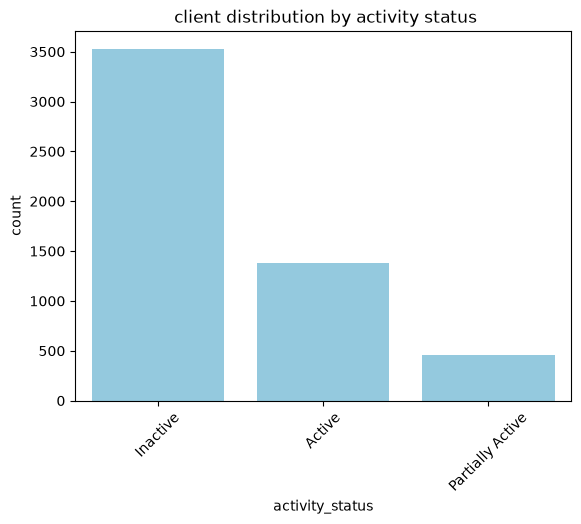

In [111]:
sns.barplot(data=activity_status,x='activity_status',y='count',color='skyblue')
plt.title(' client distribution by activity status')
plt.xticks(rotation=45)
plt.show()

In [112]:
activity_status

,activity_status,count
0,Inactive,3531
1,Active,1385
2,Partially Active,453


Customers with long periods of inactivity and declining transaction recency are most at risk of becoming dormant. The inactive segment (3,531 clients) represents the highest retention risk, while partially active customers (453 clients) are potential churn candidates requiring proactive engagement.

In [113]:
trajectory = client_account_df[
    client_account_df['tenure_years'] <= 2
].copy()

In [114]:


trajectory['period'] = np.select(
    [
        trajectory['tenure_years'] <= 1,
        trajectory['tenure_years'] <= 2
    ],
    [
        'Year 1',
        'Year 2'
    ],
    default='Other'
)

In [115]:
trajectory.groupby('period').agg(
    clients=('client_id','nunique'),
    avg_products=('total_products','mean'),
    avg_cards=('card_count','mean'),
    avg_loans=('loan_count','mean'),
    avg_orders=('order_count','mean')
).round(2)

,clients,avg_products,avg_cards,avg_loans,avg_orders
period,,,,,
Year 1,1173,2.75,0.15,0.13,1.46
Year 2,1568,2.84,0.17,0.18,1.49


Newly acquired clients generally start with a basic multi-product relationship, holding around 2.75 products in their first year. Over the second year, product adoption gradually increases to 2.84 products, mainly driven by higher loan and card adoption. This indicates that customer relationships deepen over time, with additional product uptake occurring after the initial onboarding period.

In [116]:
#### Financial Analysis

In [117]:
transaction_df['Date']=pd.to_datetime(transaction_df['Date'])

In [118]:
transaction_df['year']=transaction_df['Date'].dt.year

In [119]:
trans_volume=transaction_df.groupby('year')['trans_id'].count().reset_index(name='volume')

In [120]:
trans_volume

,year,volume
0,2017,314532
1,2018,284409
2,2019,196779
3,2020,133022
4,2021,91628
5,2022,28205


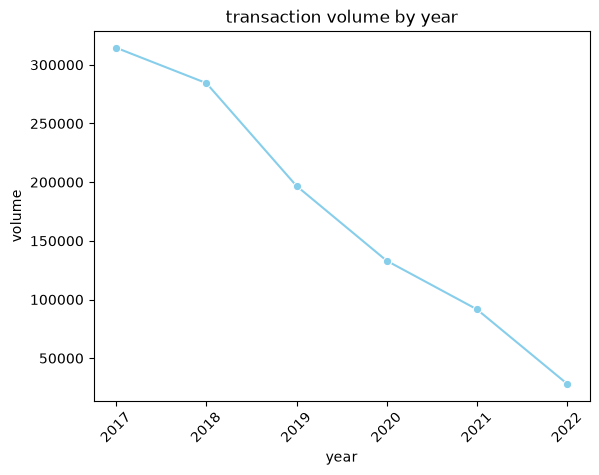

In [121]:
sns.lineplot(data=trans_volume,x='year',y='volume',color='skyblue',marker='o')
plt.title('transaction volume by year')
plt.xticks(rotation=45)
plt.show()

In [122]:
trans_value=transaction_df.groupby('year')['amount'].sum().reset_index(name='value')

In [123]:
trans_value

,year,value
0,2017,1867735412
1,2018,1688347890
2,2019,1163864249
3,2020,767739197
4,2021,538796646
5,2022,204309987


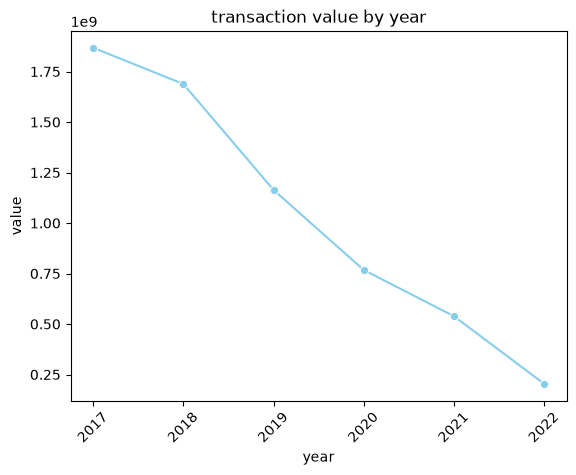

In [124]:
sns.lineplot(data=trans_value,x='year',y='value',color='skyblue',marker='o')
plt.title('transaction value by year')
plt.xticks(rotation=45)
plt.show()

In [125]:
account_transaction_df=pd.merge(left=account_df,right=transaction_df,left_on='account_id',right_on='account_id',how='right')

In [126]:
overall_avg = account_transaction_df.groupby('year')['balance'].mean().reset_index()
overall_avg

,year,balance
0,2017,40715.796113
1,2018,38965.703395
2,2019,37266.731498
3,2020,36461.633692
4,2021,35790.795390
5,2022,36286.766530


In [127]:
avg_balance_by_time=account_transaction_df.groupby(['year','Account_type'])['calculated_balance'].mean().reset_index(name='value')

In [128]:
avg_balance_by_time

,year,Account_type,value
0,2017,NRI account,41463.243347
1,2017,Salary account,41033.513410
2,2017,Savings account,39998.235157
3,2018,NRI account,39498.951322
4,2018,Salary account,38967.053224
5,2018,Savings account,38491.240474
6,2019,NRI account,38281.587693
7,2019,Salary account,36858.471933
8,2019,Savings account,37131.347921
9,2020,NRI account,37527.373465


Average account balance showed a continuous decline from 2017 to 2021.
The average balance decreased from ~40.7K in 2017 to ~35.8K in 2021.
In 2022, a slight recovery was observed (~36.3K); however, the average balance remained below the 2017 level.

In [129]:
transaction_df['month'] = transaction_df['Date'].dt.month_name()


In [130]:
month_wise_trans=transaction_df.groupby('month')['trans_id'].count().reset_index(name='count')

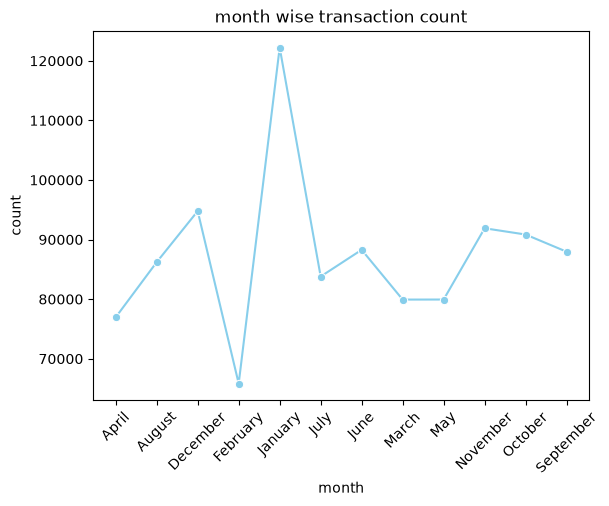

In [131]:
sns.lineplot(data=month_wise_trans,x='month',y='count',color='skyblue',marker='o')
plt.title('month wise transaction count')
plt.xticks(rotation=45)
plt.show()

In [132]:
month_wise_trans

,month,count
0,April,76954
1,August,86204
2,December,94775
3,February,65824
4,January,122214
5,July,83791
6,June,88276
7,March,79922
8,May,79931
9,November,91890


Transaction activity exhibits seasonality, with a pronounced peak in January followed by a sharp decline in February.
From March to August, transaction volumes remain relatively stable.
A gradual upward trend is observed from September onwards, culminating in another seasonal peak during December.
This pattern suggests higher customer transaction activity at the beginning and end of the year, while mid-year activity remains comparatively consistent.


In [133]:
import pandas as pd

# Convert date column to datetime
transaction_df['Date'] = pd.to_datetime(transaction_df['Date'])

# Year-wise transaction volume
yearly_transactions = (
    transaction_df
    .groupby(transaction_df['Date'].dt.year)
    .size()
    .reset_index(name='transaction_volume')
    .rename(columns={'date': 'year'})
)

# YoY Growth %
yearly_transactions['YoY_Growth_%'] = (
    yearly_transactions['transaction_volume']
    .pct_change() * 100
).round(2)

yearly_transactions

,Date,transaction_volume,YoY_Growth_%
0,2017,314532,NaN
1,2018,284409,-9.58
2,2019,196779,-30.81
3,2020,133022,-32.40
4,2021,91628,-31.12
5,2022,28205,-69.22


Transaction volume declined consistently every year from 2017 to 2022, indicating a sustained downward trend in transaction activity.
The decline was relatively moderate in 2018 (-9.58%), followed by a much sharper drop of around 31–32% per year between 2019 and 2021.
The steepest year-over-year decline occurred in 2022, when transaction volume fell by 69.22% compared to 2021.
Overall, transaction volume decreased from 314,532 in 2017 to just 28,205 in 2022, representing a significant reduction over the six-year period.


In [134]:
transaction_df['quarter'] = transaction_df['Date'].dt.to_period('Q').astype(str)

In [135]:
qoq_category = transaction_df.groupby(
    ['quarter','operation']
)['amount'].sum().reset_index()

qoq_category['QoQ_change'] = (
    qoq_category
    .groupby('operation')['amount']
    .diff()
)

In [136]:
qoq_category

,quarter,operation,amount,QoQ_change
0,2017Q1,Credit card withdrawal,4351000,NaN
1,2017Q1,Credit in cash,174836492,NaN
2,2017Q1,Electronic funds transfer,54386286,NaN
3,2017Q1,Interest Credit,1987737,NaN
4,2017Q1,Remittance to Another Bank,53919393,NaN
...,...,...,...,...
135,2022Q4,Credit in cash,39695329,12650867.0
136,2022Q4,Electronic funds transfer,13509104,4705928.0
137,2022Q4,Interest Credit,400281,138450.0
138,2022Q4,Remittance to Another Bank,6404469,3168578.0


In [137]:
qoq_category = transaction_df.groupby(
    ['quarter','operation']
)['amount'].sum().reset_index()

# Sort first
qoq_category = qoq_category.sort_values(
    ['operation','quarter']
)

# QoQ change by operation
qoq_category['QoQ_change'] = (
    qoq_category
    .groupby('operation')['amount']
    .diff()
)

qoq_category

,quarter,operation,amount,QoQ_change
0,2017Q1,Credit card withdrawal,4351000,NaN
6,2017Q2,Credit card withdrawal,1408300,-2942700.0
12,2017Q3,Credit card withdrawal,1551900,143600.0
18,2017Q4,Credit card withdrawal,2300400,748500.0
24,2018Q1,Credit card withdrawal,2047900,-252500.0
...,...,...,...,...
119,2021Q4,Withdrawal in cash,58411540,10105219.0
124,2022Q1,Withdrawal in cash,1159009,-57252531.0
129,2022Q2,Withdrawal in cash,13104156,11945147.0
134,2022Q3,Withdrawal in cash,23143907,10039751.0


In [138]:
qoq_category.sort_values(
    'QoQ_change',
    ascending=False
).head(10)


,quarter,operation,amount,QoQ_change
71,2019Q4,Withdrawal in cash,132077309,29649826.0
47,2018Q4,Withdrawal in cash,174806595,29323422.0
35,2018Q2,Withdrawal in cash,170942429,25896074.0
67,2019Q4,Credit in cash,140078437,23681513.0
31,2018Q2,Credit in cash,164479659,22188076.0
11,2017Q2,Withdrawal in cash,198926120,19381553.0
43,2018Q4,Credit in cash,181026123,18843685.0
59,2019Q2,Withdrawal in cash,109554258,18114536.0
95,2020Q4,Withdrawal in cash,82384907,16467752.0
55,2019Q2,Credit in cash,107834386,16399236.0


In [139]:
qoq_category.sort_values(
    'QoQ_change'
).head(10)

,quarter,operation,amount,QoQ_change
49,2019Q1,Credit in cash,91435150,-89590973.0
53,2019Q1,Withdrawal in cash,91439722,-83366873.0
73,2020Q1,Credit in cash,62232003,-77846434.0
77,2020Q1,Withdrawal in cash,64021727,-68055582.0
124,2022Q1,Withdrawal in cash,1159009,-57252531.0
120,2022Q1,Credit in cash,5212671,-54819387.0
17,2017Q3,Withdrawal in cash,155880621,-43045499.0
97,2021Q1,Credit in cash,42258123,-43023020.0
101,2021Q1,Withdrawal in cash,44413732,-37971175.0
25,2018Q1,Credit in cash,142291583,-32122183.0


Cash withdrawal activity was the strongest driver of positive quarter-over-quarter changes.
The largest increase was observed in Withdrawal in cash during 2019Q4, with a QoQ increase of ~29.65M, followed by 2018Q4 (~29.32M) and 2018Q2 (~25.90M).
Credit in cash was another major contributor, with significant increases in 2019Q4 (~23.68M) and 2018Q2 (~22.19M).
Overall, cash-based transaction operations (cash withdrawals and cash deposits) contributed the most to positive performance swings across quarters.


Cash-based transactions were also the main contributors to negative quarter-over-quarter swings.
The largest decline occurred in Credit in cash during 2019Q1, with a QoQ decrease of ~89.59M, making it the biggest negative driver.
Withdrawal in cash during 2019Q1 also declined significantly by ~83.37M.
2020Q1 experienced another major decline, driven by:
Credit in cash: ~-77.85M
Withdrawal in cash: ~-68.06M
2022Q1 showed a sharp drop in cash activity, especially:
Withdrawal in cash: ~-57.25M
Credit in cash: ~-54.82M

In [140]:
account_profit_proxy = account_transaction_df.groupby(
    'Account_type'
)['amount'].sum().reset_index()

In [141]:
district_transaction_df=pd.merge(left=transaction_df,right=pd.merge(left=account_df,right=district_df,left_on='district_id',right_on='district_id',how='left'),left_on='account_id',right_on='account_id',how='left')

In [142]:
district_transaction_df.groupby('district_name')['amount'].sum().reset_index()

,district_name,amount
0,Benesov,58147517
1,Beroun,55369308
2,Blansko,70953647
3,Breclav,56708046
4,Brno - mesto,150071031
...,...,...
72,Vsetin,55951255
73,Vyskov,60716608
74,Zdar nad Sazavou,89495941
75,Zlin,148493760


In [143]:
withdrawal_trend = transaction_df[
    transaction_df['Type']=='Withdrawal'
].groupby('quarter')['amount'].sum().reset_index()

In [144]:
balance_trend = transaction_df.groupby(
'quarter'
)['calculated_balance'].mean().reset_index()

In [145]:
withdrawal_trend

,quarter,amount
0,2017Q1,237814960
1,2017Q2,256787546
2,2017Q3,214575950
3,2017Q4,208736324
4,2018Q1,187005738
5,2018Q2,215572558
6,2018Q3,193845174
7,2018Q4,227229408
8,2019Q1,117535539
9,2019Q2,137426628


In [146]:
balance_trend

,quarter,calculated_balance
0,2017Q1,37631.694471
1,2017Q2,41090.390889
2,2017Q3,41446.818483
3,2017Q4,44221.577172
4,2018Q1,35740.001856
5,2018Q2,39118.434106
6,2018Q3,39436.559287
7,2018Q4,41537.467330
8,2019Q1,34243.586350
9,2019Q2,37415.183221


In [147]:
transaction_mix = transaction_df.groupby(
    ['quarter','Type']
)['amount'].sum().reset_index()

transaction_mix

,quarter,Type,amount
0,2017Q1,Credit,231210515
1,2017Q1,Withdrawal,237814960
2,2017Q2,Credit,250278408
3,2017Q2,Withdrawal,256787546
4,2017Q3,Credit,231703843
5,2017Q3,Withdrawal,214575950
6,2017Q4,Credit,236627866
7,2017Q4,Withdrawal,208736324
8,2018Q1,Credit,188303470
9,2018Q1,Withdrawal,187005738


In [148]:
transaction_mix_pivot = transaction_mix.pivot(
    index='quarter',
    columns='Type',
    values='amount'
).fillna(0)

transaction_mix_pivot

Type,Credit,Withdrawal
quarter,,
2017Q1,231210515,237814960
2017Q2,250278408,256787546
2017Q3,231703843,214575950
2017Q4,236627866,208736324
2018Q1,188303470,187005738
2018Q2,219018478,215572558
2018Q3,214633622,193845174
2018Q4,242739442,227229408
2019Q1,120721170,117535539


In [149]:
balance_growth = transaction_df.groupby(
    'quarter')['calculated_balance'].mean()
balance_growth = balance_growth.pct_change()*100

balance_growth

quarter
2017Q1          NaN
2017Q2     9.190913
2017Q3     0.867423
2017Q4     6.694745
2018Q1   -19.179721
2018Q2     9.452804
2018Q3     0.813236
2018Q4     5.327311
2019Q1   -17.559763
2019Q2     9.261871
2019Q3     0.588584
2019Q4     5.987534
2020Q1   -17.041658
2020Q2    12.205013
2020Q3     0.196467
2020Q4     4.023690
2021Q1   -14.164206
2021Q2     8.958021
2021Q3    -0.077085
2021Q4     4.631930
2022Q1   -44.354476
2022Q2    70.555930
2022Q3     2.308571
2022Q4     2.945784
Name: calculated_balance, dtype: float64

In [150]:
correlation_df = transaction_mix_pivot.copy()

correlation_df['balance_growth'] = balance_growth

correlation_df.corr()

Type,Credit,Withdrawal,balance_growth
Type,,,
Credit,1.000000,0.994322,0.033600
Withdrawal,0.994322,1.000000,0.015899
balance_growth,0.033600,0.015899,1.000000


Credit and Withdrawal transaction amounts are highly positively correlated (0.994), indicating that periods with higher credit transaction activity also tend to have higher withdrawal activity. This suggests overall transaction activity increases or decreases together.
The correlation between Credit transactions and balance growth is very weak (0.034), indicating that higher credit transaction volume alone has little influence on net balance growth.
Similarly, Withdrawal transactions show a very weak positive correlation (0.016) with balance growth, suggesting that withdrawal activity does not have a significant linear relationship with changes in account balances.
Overall, the transaction-type mix (Credit vs. Withdrawal) does not appear to be a strong driver of net balance growth. Other factors—such as transaction amounts by specific operations, account characteristics, or customer behavior—are likely to have a greater impact on balance growth.

In [151]:
monthly_performance = transaction_df.groupby(
    transaction_df['Date'].dt.month_name()
).agg(
    transaction_volume=('trans_id','count'),
    transaction_value=('amount','sum'),
    avg_balance=('calculated_balance','mean')
).reset_index()


In [152]:
month_order = ['January','February','March','April',
               'May','June','July','August',
               'September','October','November','December']

monthly_performance['Date'] = pd.Categorical(
    monthly_performance['Date'],
    categories=month_order,
    ordered=True
)

monthly_performance = monthly_performance.sort_values('Date')


In [153]:
monthly_performance['Difference_from_avg'] = (
    monthly_performance['transaction_value']
    - monthly_performance['transaction_value'].mean()
)

In [154]:
monthly_performance['Difference_from_avg']

4     2.532499e+07
3    -1.399742e+08
7    -7.555240e+07
0    -6.964411e+07
8    -4.038081e+07
6     1.494989e+08
5    -2.821802e+07
1    -1.022032e+07
11    3.327684e+06
10    2.321915e+07
9     2.383787e+07
2     1.387813e+08
Name: Difference_from_avg, dtype: float64

In [155]:
account_balance = transaction_df.sort_values('Date')

declining = account_balance.groupby(
    'account_id'
).agg(
    first_balance=('calculated_balance','first'),
    latest_balance=('calculated_balance','last')
).reset_index()

declining['balance_change'] = (
    declining['latest_balance']
    - declining['first_balance']
)

declining.sort_values('balance_change')

,account_id,first_balance,latest_balance,balance_change
1137,1196,152652.0,23840.0,-128812.0
4231,7944,104056.0,600.0,-103456.0
4106,6148,102265.0,300.0,-101965.0
4284,8628,125175.0,25445.0,-99730.0
3877,4276,127829.0,28594.0,-99235.0
...,...,...,...,...
1932,2028,11140.0,88243.0,77103.0
3434,3614,22053.0,101250.0,79197.0
1559,1641,17776.0,97803.0,80027.0
4357,9528,8977.0,90406.0,81429.0


In [156]:
from scipy.stats import zscore

transaction_df['z_score'] = zscore(
    transaction_df['amount']
)

anomalies = transaction_df[
    abs(transaction_df['z_score'])>3
]

anomalies

,trans_id,account_id,Date,Type,operation,amount,balance,Purpose,bank,account_partner_id,calculated_balance,year,month,quarter,z_score
417,538,2,2018-06-14,Withdrawal,Withdrawal in cash,42000,27302.000000,NaN,Southern Bank,NaN,27276.0,2018,June,2018Q2,3.783872
1336,1998,8,2017-06-07,Withdrawal,Withdrawal in cash,40800,31321.199219,NaN,NaN,NaN,25313.0,2017,June,2017Q2,3.657945
1443,2181,9,2020-12-16,Credit,Credit in cash,45691,78519.398438,NaN,NaN,NaN,78504.0,2020,December,2020Q4,4.171201
1448,2186,9,2018-10-04,Credit,Credit in cash,35759,51422.101562,NaN,Southern Bank,NaN,51399.0,2018,October,2018Q4,3.128948
1717,2485,9,2018-11-02,Withdrawal,Withdrawal in cash,38100,47329.699219,NaN,Southern Bank,NaN,47306.0,2018,November,2018Q4,3.374610
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
868255,3431103,11382,2017-06-10,Credit,Electronic funds transfer,46248,86593.898438,NaN,Fio bank,62510245,86585.0,2017,June,2017Q2,4.229652
868261,3431109,11382,2017-12-10,Credit,Electronic funds transfer,46248,87362.398438,NaN,Fio bank,62510245,87352.0,2017,December,2017Q4,4.229652
868277,3431144,11382,2017-06-17,Withdrawal,Withdrawal in cash,52800,33793.898438,NaN,NaN,NaN,33785.0,2017,June,2017Q2,4.917212
868348,3431248,11382,2020-12-18,Withdrawal,Withdrawal in cash,36000,57550.199219,NaN,NaN,NaN,57549.0,2020,December,2020Q4,3.154238


In [157]:
yearly = transaction_df.groupby(
    transaction_df['Date'].dt.year
)['amount'].sum().reset_index()

current = yearly.iloc[-1]['amount']

In [158]:
projection = pd.DataFrame({
    'Scenario':['5%','10%','15%'],
    'Projected_Revenue':[
        current*1.05,
        current*1.10,
        current*1.15
    ]
})

projection

,Scenario,Projected_Revenue
0,5%,2.145255e+08
1,10%,2.247410e+08
2,15%,2.349565e+08


In [159]:
client_balance = (
    disposition_df
    .merge(client_df,on='client_id')
    .merge(
        transaction_df[['account_id','calculated_balance']],
        on='account_id'
    )
)

In [160]:
high_value = client_balance.groupby(
    'client_id'
)['calculated_balance'].mean().reset_index()

high_value = high_value.sort_values(
    'calculated_balance',
    ascending=False
)

high_value.head(20)

,client_id,calculated_balance
1835,1946,110098.979310
436,458,88575.985423
3215,3395,86875.008772
3273,3458,82473.478070
5076,10145,81192.035165
4654,5204,79635.943820
5309,13172,79276.806452
2483,2617,79247.862500
2482,2616,79247.862500
444,467,78734.011765


In [161]:
## product performance analysis

In [162]:
account_type_distribution = account_transaction_df.groupby(
    'Account_type'
).agg(
    total_accounts=('account_id','nunique'),
    avg_balance=('calculated_balance','mean')
).reset_index()

account_type_distribution

,Account_type,total_accounts,avg_balance
0,NRI account,1522,39337.445969
1,Salary account,1445,38315.059321
2,Savings account,1533,38171.776305


In [163]:
card_mix = card_df.groupby(
    'Reporting_card_type'
)['card_id'].count().reset_index(name='card_count')

card_mix

,Reporting_card_type,card_count
0,Diamond,88
1,Gold,659
2,Silver,145


In [164]:
card_df['issued'] = pd.to_datetime(card_df['issued'])

card_df['year'] = card_df['issued'].dt.year

In [165]:
card_trend = card_df.groupby(
    ['year','Reporting_card_type']
)['card_id'].count().reset_index(name='count')

card_trend

,year,Reporting_card_type,count
0,2016,Gold,2
1,2017,Gold,20
2,2017,Silver,6
3,2018,Diamond,5
4,2018,Gold,43
5,2018,Silver,15
6,2019,Diamond,8
7,2019,Gold,96
8,2019,Silver,31
9,2020,Diamond,23


In [166]:
disp_card = disposition_df.merge(
    card_df,
    on='disp_id',
    how='left'
)

card_penetration = (
    disp_card['card_id']
    .notna()
    .mean()*100
)

card_penetration

np.float64(16.613894579996273)

In [167]:
frequency_distribution = account_df.groupby(
    'frequency'
)['account_id'].count().reset_index(name='count')

frequency_distribution

,frequency,count
0,After Transaction,93
1,Monthly Issuance,4167
2,Weekly Issuanace,240


In [168]:
frequency_account = account_df.groupby(
    ['Account_type','frequency']
)['account_id'].count().reset_index(name='count')

frequency_account

,Account_type,frequency,count
0,NRI account,After Transaction,34
1,NRI account,Monthly Issuance,1398
2,NRI account,Weekly Issuanace,90
3,Salary account,After Transaction,33
4,Salary account,Monthly Issuance,1332
5,Salary account,Weekly Issuanace,80
6,Savings account,After Transaction,26
7,Savings account,Monthly Issuance,1437
8,Savings account,Weekly Issuanace,70


In [169]:
account_card = (
    account_df[['account_id','date']]
    .merge(
        disposition_df[['account_id','disp_id']],
        on='account_id',
        how='inner'
    )
    .merge(
        card_df[['disp_id','issued']],
        on='disp_id',
        how='inner'
    )
)

account_card.head()

,account_id,date,disp_id,issued
0,7,2021-11-24,9,2021-09-30
1,14,2021-11-27,19,2021-02-28
2,33,2018-08-26,41,2018-08-31
3,34,2018-09-17,42,2021-10-31
4,43,2019-06-12,51,2018-03-31


In [170]:
account_card['date'] = pd.to_datetime(
    account_card['date'],
    errors='coerce'
)

account_card['issued'] = pd.to_datetime(
    account_card['issued'],
    errors='coerce'
)

account_card.dtypes

account_id             int64
date          datetime64[us]
disp_id                int64
issued        datetime64[us]
dtype: object

In [171]:
first_card = (
    account_card
    .groupby('account_id')['issued']
    .min()
    .reset_index()
)

first_card.head()

,account_id,issued
0,7,2021-09-30
1,14,2021-02-28
2,33,2018-08-31
3,34,2021-10-31
4,43,2018-03-31


In [172]:
first_card = first_card.merge(
    account_df[['account_id','date']],
    on='account_id',
    how='left'
)

first_card.head()

,account_id,issued,date
0,7,2021-09-30,2021-11-24
1,14,2021-02-28,2021-11-27
2,33,2018-08-31,2018-08-26
3,34,2021-10-31,2018-09-17
4,43,2018-03-31,2019-06-12


In [173]:
first_card['issued'] = pd.to_datetime(
    first_card['issued'],
    errors='coerce'
)

first_card['date'] = pd.to_datetime(
    first_card['date'],
    errors='coerce'
)

first_card.dtypes

account_id             int64
issued        datetime64[us]
date          datetime64[us]
dtype: object

In [174]:
first_card['days_to_first_card'] = (
    first_card['issued'] -
    first_card['date']
).dt.days

first_card.head()

,account_id,issued,date,days_to_first_card
0,7,2021-09-30,2021-11-24,-55
1,14,2021-02-28,2021-11-27,-272
2,33,2018-08-31,2018-08-26,5
3,34,2021-10-31,2018-09-17,1140
4,43,2018-03-31,2019-06-12,-438


In [175]:
average_days = first_card['days_to_first_card'].mean()

round(average_days,2)

np.float64(31.08)

In [176]:
owner_user_card = (
    disposition_df[['disp_id','type']]
    .merge(
        card_df[['disp_id','card_id']],
        on='disp_id',
        how='left'
    )
)

adoption_by_type = owner_user_card.groupby('type').agg(
    total_users=('disp_id','count'),
    card_holders=('card_id', lambda x: x.notna().sum())
).reset_index()

adoption_by_type['card_adoption_rate_%'] = (
    adoption_by_type['card_holders'] /
    adoption_by_type['total_users']
)*100

adoption_by_type

,type,total_users,card_holders,card_adoption_rate_%
0,OWNER,4500,892,19.822222
1,USER,869,0,0.000000


In [177]:
### diagnostic

In [178]:
card_transaction = (
    disposition_df[['disp_id','account_id']]
    .merge(
        card_df[['disp_id','Reporting_card_type']],
        on='disp_id',
        how='inner'
    )
    .merge(
        transaction_df,
        on='account_id',
        how='inner'
    )
)

In [179]:
gold_classic_pattern = card_transaction.groupby(
    'Reporting_card_type'
).agg(
    transaction_count=('trans_id','count'),
    avg_transaction_amount=('amount','mean'),
    total_transaction_value=('amount','sum'),
    avg_balance=('calculated_balance','mean')
).reset_index()

gold_classic_pattern

,Reporting_card_type,transaction_count,avg_transaction_amount,total_transaction_value,avg_balance
0,Diamond,25573,9131.824502,233528148,61714.835100
1,Gold,158604,8657.956962,1373186606,52212.608843
2,Silver,36078,7657.960114,276283885,49708.994484


In [180]:
district_card = (
    disposition_df[['client_id','disp_id']]
    .merge(client_df[['client_id','district_id']],on='client_id')
    .merge(card_df[['disp_id','card_id']],on='disp_id',how='left')
)


district_adoption = district_card.groupby(
    'district_id'
).agg(
    clients=('client_id','nunique'),
    card_users=('card_id',lambda x:x.notna().sum())
).reset_index()


district_adoption['adoption_rate_%'] = (
    district_adoption['card_users'] /
    district_adoption['clients']
)*100


district_adoption.sort_values('adoption_rate_%').head(10)

,district_id,clients,card_users,adoption_rate_%
24,25,48,2,4.166667
55,56,54,3,5.555556
54,55,63,6,9.523810
49,50,61,6,9.836066
76,77,50,5,10.000000
61,62,59,6,10.169492
48,49,46,5,10.869565
42,43,55,6,10.909091
53,54,155,17,10.967742
16,17,54,6,11.111111


In [181]:
age_card = (
    client_account_df[['client_id','age_group']]
    .merge(
        disposition_df[['client_id','disp_id']],
        on='client_id',
        how='inner'
    )
    .merge(
        card_df[['disp_id','card_id']],
        on='disp_id',
        how='left'
    )
)


age_adoption = age_card.groupby(
    'age_group',
    observed=True
).agg(
    total_clients=('client_id','nunique'),
    card_users=('card_id', lambda x: x.notna().sum())
).reset_index()


age_adoption['adoption_rate_%'] = (
    age_adoption['card_users'] /
    age_adoption['total_clients'] * 100
)


age_adoption

,age_group,total_clients,card_users,adoption_rate_%
0,26-60,2203,458,20.789832
1,60+,3060,432,14.117647


In [182]:
account_products = account_df[['account_id','Account_type']].copy()

account_products['has_loan'] = (
    account_products['account_id']
    .isin(loan_df['account_id'])
)


loan_by_account_type = (
    account_products
    .groupby('Account_type')['has_loan']
    .mean()
    .reset_index()
)

loan_by_account_type['loan_percentage'] = (
    loan_by_account_type['has_loan'] * 100
)

loan_by_account_type

,Account_type,has_loan,loan_percentage
0,NRI account,0.142576,14.257556
1,Salary account,0.158478,15.847751
2,Savings account,0.153947,15.394651


In [183]:
account_products['has_order'] = (
    account_products['account_id']
    .isin(order_df['account_id'])
)


order_by_account_type = (
    account_products
    .groupby('Account_type')['has_order']
    .mean()
    .reset_index()
)

order_by_account_type['order_percentage'] = (
    order_by_account_type['has_order'] * 100
)

order_by_account_type

,Account_type,has_order,order_percentage
0,NRI account,0.840342,84.034166
1,Salary account,0.837370,83.737024
2,Savings account,0.827789,82.778865


In [184]:
card_usage = (
    disposition_df[['account_id','disp_id']]
    .merge(
        card_df[['disp_id','Reporting_card_type']],
        on='disp_id',
        how='inner'
    )
    .merge(
        transaction_df,
        on='account_id',
        how='inner'
    )
)


card_utilisation = card_usage.groupby(
    ['account_id','Reporting_card_type']
).agg(
    transaction_count=('trans_id','count'),
    total_transaction_value=('amount','sum'),
    avg_balance=('calculated_balance','mean')
).reset_index()


card_utilisation.head()

,account_id,Reporting_card_type,transaction_count,total_transaction_value,avg_balance
0,7,Diamond,128,1185827,62385.640625
1,14,Gold,122,780889,39528.827869
2,33,Diamond,343,3231584,72188.064140
3,34,Gold,406,4308599,54113.583744
4,43,Silver,319,2840651,60882.335423


In [185]:
card_utilisation['usage_segment'] = pd.qcut(
    card_utilisation['transaction_count'],
    q=3,
    labels=['Low','Medium','High']
)


card_utilisation.groupby(
    'usage_segment',
    observed=True
).mean(numeric_only=True)

,account_id,transaction_count,total_transaction_value,avg_balance
usage_segment,,,,
Low,2644.013378,115.531773,1.015404e+06,49526.464762
Medium,2884.114865,226.645270,1.894757e+06,51368.645000
High,3213.791246,399.407407,3.429443e+06,54438.243841


In [186]:
card_df['issued'] = pd.to_datetime(card_df['issued'])

card_growth = (
    card_df
    .groupby([
        card_df['issued'].dt.year,
        'Reporting_card_type'
    ])
    .size()
    .reset_index(name='card_count')
)


card_growth

,issued,Reporting_card_type,card_count
0,2016,Gold,2
1,2017,Gold,20
2,2017,Silver,6
3,2018,Diamond,5
4,2018,Gold,43
5,2018,Silver,15
6,2019,Diamond,8
7,2019,Gold,96
8,2019,Silver,31
9,2020,Diamond,23


In [187]:
frequency_product = account_df[['account_id','frequency']].copy()


frequency_product['has_loan'] = (
    frequency_product['account_id']
    .isin(loan_df['account_id'])
)


frequency_product['has_order'] = (
    frequency_product['account_id']
    .isin(order_df['account_id'])
)


frequency_analysis = (
    frequency_product
    .groupby('frequency')
    [['has_loan','has_order']]
    .mean()
    *100
)


frequency_analysis

,has_loan,has_order
frequency,,
After Transaction,34.408602,83.870968
Monthly Issuance,13.414927,83.801296
Weekly Issuanace,37.916667,78.333333


In [188]:
classic_users = (
    disposition_df[['account_id','disp_id']]
    .merge(
        card_df[['disp_id','Reporting_card_type']],
        on='disp_id'
    )
)


classic_users = classic_users[
    classic_users['Reporting_card_type']=='Classic'
]


classic_transaction = classic_users.merge(
    transaction_df,
    on='account_id',
    how='inner'
)


upgrade_candidates = classic_transaction.groupby(
    'account_id'
).agg(
    transaction_count=('trans_id','count'),
    total_spend=('amount','sum'),
    avg_balance=('calculated_balance','mean')
).reset_index()


upgrade_candidates.sort_values(
    ['avg_balance','transaction_count'],
    ascending=False
).head(20)

,account_id,transaction_count,total_spend,avg_balance


In [189]:
product_combo = account_df[['account_id','Account_type']].copy()


product_combo['has_card'] = (
    product_combo['account_id']
    .isin(disposition_df['account_id'])
)


product_combo['has_loan'] = (
    product_combo['account_id']
    .isin(loan_df['account_id'])
)


product_combo['has_order'] = (
    product_combo['account_id']
    .isin(order_df['account_id'])
)


product_combo.groupby(
    ['Account_type','has_card','has_loan','has_order']
).size().reset_index(name='customers')

,Account_type,has_card,has_loan,has_order,customers
0,NRI account,True,False,False,243
1,NRI account,True,False,True,1062
2,NRI account,True,True,True,217
3,Salary account,True,False,False,235
4,Salary account,True,False,True,981
5,Salary account,True,True,True,229
6,Savings account,True,False,False,264
7,Savings account,True,False,True,1033
8,Savings account,True,True,True,236


In [190]:
def recommend(row):
    if row['has_card']==False:
        return 'Card'
    elif row['has_loan']==False:
        return 'Loan'
    elif row['has_order']==False:
        return 'Standing Order'
    else:
        return 'Premium Product'


product_combo['recommended_product'] = (
    product_combo.apply(recommend,axis=1)
)


product_combo.head()

,account_id,Account_type,has_card,has_loan,has_order,recommended_product
0,1,NRI account,True,False,True,Loan
1,2,Salary account,True,True,True,Premium Product
2,3,NRI account,True,False,True,Loan
3,4,Salary account,True,False,True,Loan
4,5,Savings account,True,False,True,Loan


In [191]:
profitability = (
    account_transaction_df
    .groupby('Account_type')
    .agg(
        avg_balance=('calculated_balance','mean'),
        transaction_value=('amount','sum'),
        transaction_volume=('trans_id','count')
    )
    .reset_index()
)


profitability

,Account_type,avg_balance,transaction_value,transaction_volume
0,NRI account,39337.445969,2135307333,349107
1,Salary account,38315.059321,1977856092,342879
2,Savings account,38171.776305,2117629956,356589


In [192]:
client_risk = (
    transaction_df
    .sort_values('Date')
    .groupby('account_id')
    .agg(
        first_balance=('calculated_balance','first'),
        last_balance=('calculated_balance','last'),
        transactions=('trans_id','count')
    )
    .reset_index()
)


client_risk['balance_change'] = (
    client_risk['last_balance']
    -
    client_risk['first_balance']
)


client_risk.sort_values(
    'balance_change'
).head(20)

,account_id,first_balance,last_balance,transactions,balance_change
1137,1196,152652.0,23840.0,191,-128812.0
4231,7944,104056.0,600.0,329,-103456.0
4106,6148,102265.0,300.0,415,-101965.0
4284,8628,125175.0,25445.0,181,-99730.0
3877,4276,127829.0,28594.0,309,-99235.0
4144,6701,113567.0,18185.0,478,-95382.0
2961,3114,128221.0,36777.0,159,-91444.0
1345,1417,91335.0,200.0,278,-91135.0
2629,2763,100554.0,11242.0,460,-89312.0
4161,6985,124880.0,40365.0,281,-84515.0


In [193]:
card_transaction = (
    disposition_df[['account_id','disp_id']]
    .merge(
        card_df[['disp_id','Reporting_card_type']],
        on='disp_id'
    )
    .merge(
        transaction_df,
        on='account_id'
    )
)


gold_avg = (
    card_transaction[
        card_transaction['Reporting_card_type']=='Gold'
    ]['amount'].mean()
)


classic_avg = (
    card_transaction[
        card_transaction['Reporting_card_type']=='Classic'
    ]['amount'].mean()
)


classic_count = (
    card_transaction[
        card_transaction['Reporting_card_type']=='Classic'
    ]['account_id'].nunique()
)


expected_revenue_impact = (
    gold_avg - classic_avg
) * classic_count


expected_revenue_impact

np.float64(nan)

In [194]:
### Loan portfolio analysis

In [195]:
loan_status_analysis = loan_df.groupby('status').agg(
    loan_count=('loan_id','count'),
    total_loan_amount=('amount','sum'),
    average_loan_amount=('amount','mean')
).reset_index()

loan_status_analysis

,status,loan_count,total_loan_amount,average_loan_amount
0,Client in Deb,45,11217804,249284.533333
1,Contract Finished,203,18603216,91641.458128
2,Loan Not Paid,31,4362348,140720.903226
3,Running Contract,403,69078372,171410.352357


In [196]:
loan_duration_status = loan_df.groupby('status').agg(
    avg_duration=('duration','mean'),
    avg_monthly_payment=('payments','mean')
).reset_index()

loan_duration_status

,status,avg_duration,avg_monthly_payment
0,Client in Deb,46.133333,5286.644444
1,Contract Finished,22.226601,4264.137931
2,Loan Not Paid,25.548387,5396.258065
3,Running Contract,43.444169,3938.535980


In [197]:
loan_df['date'] = pd.to_datetime(loan_df['date'])

loan_year_trend = loan_df.groupby(
    loan_df['date'].dt.year
).agg(
    loan_volume=('loan_id','count'),
    total_amount=('amount','sum')
).reset_index()

loan_year_trend

,date,loan_volume,total_amount
0,2016,20,2619276
1,2017,101,13379904
2,2018,90,13344372
3,2019,117,18317676
4,2020,196,30731364
5,2021,158,24869148


In [198]:
loan_district = (
    loan_df
    .merge(
        account_df[['account_id','district_id']],
        on='account_id',
        how='left'
    )
)


loan_by_district = loan_district.groupby(
    'district_id'
).agg(
    loan_count=('loan_id','count'),
    total_amount=('amount','sum')
).reset_index()


loan_by_district

,district_id,loan_count,total_amount
0,1,84,12932412
1,2,6,887952
2,3,6,1460796
3,4,7,1106520
4,5,10,1901160
...,...,...,...
72,73,8,1493076
73,74,20,3260220
74,75,4,695628
75,76,5,829644


In [199]:
loan_df['amount_band'] = pd.cut(
    loan_df['amount'],
    bins=[0,50000,100000,200000,500000,1000000],
    labels=[
        '0-50K',
        '50K-100K',
        '100K-200K',
        '200K-500K',
        '500K+'
    ]
)


loan_amount_distribution = loan_df.groupby(
    'amount_band',
    observed=True
).agg(
    loan_count=('loan_id','count'),
    total_exposure=('amount','sum')
).reset_index()


loan_amount_distribution

,amount_band,loan_count,total_exposure
0,0-50K,126,4023816
1,50K-100K,179,13796184
2,100K-200K,192,28826376
3,200K-500K,180,53874204
4,500K+,5,2741160


In [200]:
finished_loans = loan_df[
    loan_df['status']=="Contract Finished"
]

finished_summary = finished_loans.groupby('status').agg(
    loan_count=('loan_id','count'),
    average_duration=('duration','mean'),
    average_payment=('payments','mean')
).reset_index()

finished_summary

,status,loan_count,average_duration,average_payment
0,Contract Finished,203,22.226601,4264.137931


In [201]:
loan_account_type = (
    loan_df
    .merge(
        account_df[['account_id','Account_type']],
        on='account_id',
        how='left'
    )
)

loan_account_analysis = loan_account_type.groupby(
    'Account_type'
).agg(
    loan_count=('loan_id','count'),
    average_loan_amount=('amount','mean'),
    total_loan_amount=('amount','sum')
).reset_index()

loan_account_analysis

,Account_type,loan_count,average_loan_amount,total_loan_amount
0,NRI account,217,159113.861751,34527708
1,Salary account,229,152913.275109,35017140
2,Savings account,236,142868.186441,33716892


In [202]:
loan_risk_district = (
    loan_district
    .merge(
        district_df[
            [
            'district_id',
            'average_salary',
            'unemployment_rates2'
            ]
        ],
        on='district_id',
        how='left'
    )
)


district_risk = loan_risk_district.groupby('district_id').agg(
    total_loans=('loan_id','count'),
    debt_loans=('status',
                lambda x:(x=="Client in Debt").sum()),
    avg_salary=('average_salary','mean'),
    unemployment=('unemployment_rates2','mean')
).reset_index()


district_risk['debt_rate_%'] = (
    district_risk['debt_loans'] /
    district_risk['total_loans']*100
)

district_risk.sort_values(
    'debt_rate_%',
    ascending=False
)

,district_id,total_loans,debt_loans,avg_salary,unemployment,debt_rate_%
0,1,84,0,12541.0,0.43,0.0
1,2,6,0,8507.0,1.85,0.0
2,3,6,0,8980.0,2.21,0.0
3,4,7,0,9753.0,5.05,0.0
4,5,10,0,9307.0,4.43,0.0
...,...,...,...,...,...,...
72,73,8,0,8746.0,3.74,0.0
73,74,20,0,10673.0,5.44,0.0
74,75,4,0,8819.0,5.66,0.0
75,76,5,0,8369.0,5.88,0.0


In [203]:
loan_df['duration_group'] = pd.cut(
    loan_df['duration'],
    bins=[0,24,48,100],
    labels=[
        'Short Term',
        'Medium Term',
        'Long Term'
    ]
)


duration_risk = loan_df.groupby(
    'duration_group',
    observed=True
).agg(
    total_loans=('loan_id','count'),
    problem_loans=(
        'status',
        lambda x:
        ((x=="Loan Not Paid") |
         (x=="Client in Debt")).sum()
    )
).reset_index()


duration_risk['problem_rate_%'] = (
    duration_risk['problem_loans'] /
    duration_risk['total_loans']*100
)

duration_risk

,duration_group,total_loans,problem_loans,problem_rate_%
0,Short Term,269,21,7.806691
1,Medium Term,268,9,3.358209
2,Long Term,145,1,0.689655


In [204]:
loan_transaction = (
    loan_df
    .merge(
        transaction_df,
        on='account_id',
        how='left'
    )
)


status_behavior = loan_transaction.groupby(
    'status'
).agg(
    avg_transaction_amount=('amount_y','mean'),
    transaction_count=('trans_id','count'),
    avg_balance=('calculated_balance','mean')
).reset_index()


status_behavior

,status,avg_transaction_amount,transaction_count,avg_balance
0,Client in Deb,8321.432172,11190,35343.770152
1,Contract Finished,8306.591284,78776,47796.720753
2,Loan Not Paid,8464.703365,11381,36205.651876
3,Running Contract,8259.125490,88756,46157.170862


In [205]:
product_count = account_df[['account_id']].copy()


product_count['loan'] = 1
product_count['card'] = (
    product_count['account_id']
    .isin(disposition_df['account_id'])
)


product_count['order'] = (
    product_count['account_id']
    .isin(order_df['account_id'])
)


product_count['total_products'] = (
    product_count[['loan','card','order']]
    .sum(axis=1)
)


loan_product = (
    loan_df
    .merge(
        product_count[['account_id','total_products']],
        on='account_id'
    )
)


loan_product.groupby(
    'total_products'
)['status'].value_counts().reset_index()

,total_products,status,count
0,3,Running Contract,403
1,3,Contract Finished,203
2,3,Client in Deb,45
3,3,Loan Not Paid,31


In [206]:
loan_frequency = (
    loan_df
    .merge(
        account_df[['account_id','frequency']],
        on='account_id'
    )
)


loan_frequency.groupby(
    ['frequency','status']
).size().reset_index()

,frequency,status,0
0,After Transaction,Client in Deb,3
1,After Transaction,Contract Finished,8
2,After Transaction,Loan Not Paid,3
3,After Transaction,Running Contract,18
4,Monthly Issuance,Client in Deb,37
5,Monthly Issuance,Contract Finished,168
6,Monthly Issuance,Loan Not Paid,22
7,Monthly Issuance,Running Contract,332
8,Weekly Issuanace,Client in Deb,5
9,Weekly Issuanace,Contract Finished,27


In [ ]:
### operational efficiency

In [207]:
operation_summary = transaction_df.groupby(
    'operation'
).agg(
    transaction_volume=('trans_id','count'),
    transaction_value=('amount','sum'),
    average_transaction=('amount','mean')
).reset_index()

operation_summary

,operation,transaction_volume,transaction_value,average_transaction
0,Credit card withdrawal,7706,17426500,2261.419673
1,Credit in cash,156320,2408179630,15405.447991
2,Electronic funds transfer,65226,781479953,11981.111106
3,Interest Credit,178663,26676390,149.311217
4,Remittance to Another Bank,208283,672638484,3229.444957
5,Withdrawal in cash,432377,2324392424,5375.846597


In [208]:
transaction_df['channel'] = np.where(
    transaction_df['operation'].str.contains(
        'cash',
        case=False,
        na=False
    ),
    'Cash',
    'Digital'
)

channel_summary = transaction_df.groupby(
    'channel'
).agg(
    transaction_count=('trans_id','count'),
    transaction_value=('amount','sum')
).reset_index()

channel_summary['transaction_share_%'] = (
    channel_summary['transaction_count']
    /
    channel_summary['transaction_count'].sum()
    *100
)

channel_summary

,channel,transaction_count,transaction_value,transaction_share_%
0,Cash,588697,4732572054,56.142574
1,Digital,459878,1498221327,43.857426


In [209]:
operation_bank = transaction_df.groupby(
    ['operation','bank']
).agg(
    transaction_count=('trans_id','count'),
    avg_transaction=('amount','mean'),
    total_amount=('amount','sum')
).reset_index()

operation_bank

,operation,bank,transaction_count,avg_transaction,total_amount
0,Credit card withdrawal,DBS Bank,65,2195.384615,142700
1,Credit card withdrawal,Sky Bank,926,2191.036717,2028900
2,Credit card withdrawal,Southern Bank,2166,2276.223453,4930300
3,Credit in cash,DBS Bank,13677,15158.006069,207316049
4,Credit in cash,Sky Bank,36941,14768.609404,545567200
5,Credit in cash,Southern Bank,41628,15614.005069,649979803
6,Electronic funds transfer,Air Bank,5017,12468.104445,62552480
7,Electronic funds transfer,Bank Creditas,5393,13411.269052,72326974
8,Electronic funds transfer,Czech export bank,5344,11760.208271,62846553
9,Electronic funds transfer,Fio bank,4846,12608.050144,61098611


In [210]:
transaction_df['year_month'] = (
    transaction_df['Date']
    .dt.to_period('M')
)

monthly_transaction = transaction_df.groupby(
    ['account_id','year_month']
).size().reset_index(name='transaction_count')

average_monthly = (
    monthly_transaction['transaction_count']
    .mean()
)

average_monthly

np.float64(5.667145876007285)

In [211]:
monthly_transaction

,account_id,year_month,transaction_count
0,1,2017-01,10
1,1,2017-02,5
2,1,2017-03,5
3,1,2017-04,6
4,1,2017-05,4
...,...,...,...
185022,11382,2020-08,1
185023,11382,2020-09,4
185024,11382,2020-10,4
185025,11382,2020-11,4


In [212]:
partner_bank = transaction_df.groupby(
    'bank'
).agg(
    transaction_volume=('trans_id','count'),
    transaction_value=('amount','sum')
).reset_index()

partner_bank = partner_bank.sort_values(
    'transaction_volume',
    ascending=False
)

partner_bank

,bank,transaction_volume,transaction_value
13,Southern Bank,210877,1298563938
12,Sky Bank,169861,1062626250
3,DBS Bank,68763,416029297
4,Fio bank,22285,117946302
7,Kameron bank,21720,108354954
1,Bank Creditas,21711,127567424
0,Air Bank,21582,113133689
9,Moneta Money Bank,21499,125956320
14,Trinity Bank,21293,108391770
11,Raiffeisen bank,21234,110647830


In [213]:
operation_efficiency = transaction_df.groupby(
    'operation'
).agg(
    transaction_volume=('trans_id','count'),
    transaction_value=('amount','sum')
).reset_index()

operation_efficiency['avg_value_per_transaction'] = (
    operation_efficiency['transaction_value']
    /
    operation_efficiency['transaction_volume']
)

operation_efficiency.sort_values(
    'transaction_volume',
    ascending=False
)

,operation,transaction_volume,transaction_value,avg_value_per_transaction
5,Withdrawal in cash,432377,2324392424,5375.846597
4,Remittance to Another Bank,208283,672638484,3229.444957
3,Interest Credit,178663,26676390,149.311217
1,Credit in cash,156320,2408179630,15405.447991
2,Electronic funds transfer,65226,781479953,11981.111106
0,Credit card withdrawal,7706,17426500,2261.419673


In [214]:
transaction_df['day_name'] = (
    transaction_df['Date']
    .dt.day_name()
)

weekday_volume = transaction_df.groupby(
    'day_name'
).agg(
    transaction_count=('trans_id','count'),
    transaction_value=('amount','sum')
).reset_index()

weekday_volume

,day_name,transaction_count,transaction_value
0,Friday,161285,891138628
1,Monday,143851,880734037
2,Saturday,143910,875896695
3,Sunday,139440,882176923
4,Thursday,149559,903074559
5,Tuesday,160891,899380119
6,Wednesday,149639,898392420


In [215]:
transaction_df['month_end'] = np.where(
    transaction_df['Date'].dt.day >= 25,
    'Month End',
    'Normal Days'
)

month_end_volume = transaction_df.groupby(
    'month_end'
).agg(
    transaction_count=('trans_id','count'),
    transaction_value=('amount','sum')
).reset_index()

month_end_volume

,month_end,transaction_count,transaction_value
0,Month End,401283,737169563
1,Normal Days,647292,5493623818


In [216]:
cash_transaction = transaction_df[
    transaction_df['operation']
    .str.contains('cash',case=False,na=False)
]

cash_district = (
    cash_transaction
    .merge(
        account_df[['account_id','district_id','Account_type']],
        on='account_id',
        how='left'
    )
)

cash_summary = cash_district.groupby(
    ['district_id','Account_type']
).agg(
    cash_transactions=('trans_id','count'),
    cash_value=('amount','sum')
).reset_index()

cash_summary

,district_id,Account_type,cash_transactions,cash_value
0,1,NRI account,24656,202913383
1,1,Salary account,23970,195592802
2,1,Savings account,26417,223725056
3,2,NRI account,2021,19124607
4,2,Salary account,1667,8522977
...,...,...,...,...
226,76,Salary account,3409,22936617
227,76,Savings account,2540,26016036
228,77,NRI account,1585,9328157
229,77,Salary account,2951,20860701


In [217]:
missing_operation = transaction_df.groupby(
    'operation'
).agg(
    missing_bank=('bank',
                  lambda x:x.isna().sum()),
    missing_partner=('account_partner_id',
                     lambda x:x.isna().sum()),
    total_transactions=('trans_id','count')
).reset_index()

missing_operation['missing_bank_%'] = (
    missing_operation['missing_bank']
    /
    missing_operation['total_transactions']
    *100
)

missing_operation['missing_partner_%'] = (
    missing_operation['missing_partner']
    /
    missing_operation['total_transactions']
    *100
)

missing_operation

,operation,missing_bank,missing_partner,total_transactions,missing_bank_%,missing_partner_%
0,Credit card withdrawal,4549,0,7706,59.031923,0.000000
1,Credit in cash,64074,156320,156320,40.988997,100.000000
2,Electronic funds transfer,0,0,65226,0.000000,0.000000
3,Interest Credit,73081,178663,178663,40.904384,100.000000
4,Remittance to Another Bank,0,1,208283,0.000000,0.000480
5,Withdrawal in cash,183861,418589,432377,42.523307,96.811116


In [218]:
district_processing = (
    transaction_df
    .merge(
        account_df[['account_id','district_id']],
        on='account_id',
        how='left'
    )
    .merge(
        district_df[['district_id','population']],
        on='district_id',
        how='left'
    )
)

processing_population = district_processing.groupby(
    ['district_id','population']
).agg(
    transaction_count=('trans_id','count')
).reset_index()

processing_population['transactions_per_capita'] = (
    processing_population['transaction_count']
    /
    processing_population['population']
)

processing_population.sort_values(
    'transactions_per_capita',
    ascending=False
)

,district_id,population,transaction_count,transactions_per_capita
18,19,51428,12796,0.248814
30,31,51313,12468,0.242979
68,69,42821,10338,0.241424
28,29,45714,10301,0.225336
14,15,58796,11534,0.196170
...,...,...,...,...
33,34,125236,7860,0.062762
56,57,161954,9604,0.059301
70,71,161227,9251,0.057379
25,26,170449,9685,0.056821


In [219]:
district_load = (
    transaction_df
    .merge(
        account_df[['account_id','district_id']],
        on='account_id',
        how='left'
    )
)

district_year = district_load.groupby(
    [
        'district_id',
        district_load['Date'].dt.year
    ]
).agg(
    transaction_volume=('trans_id','count')
).reset_index()

district_year['forecast_next_year'] = (
    district_year.groupby('district_id')
    ['transaction_volume']
    .shift(1)
)

district_year

,district_id,Date,transaction_volume,forecast_next_year
0,1,2017,39224,NaN
1,1,2018,35490,39224.0
2,1,2019,24218,35490.0
3,1,2020,17172,24218.0
4,1,2021,11983,17172.0
...,...,...,...,...
457,77,2018,2753,2861.0
458,77,2019,1902,2753.0
459,77,2020,1256,1902.0
460,77,2021,908,1256.0


In [220]:
from scipy.stats import zscore

transaction_df['z_score'] = zscore(
    transaction_df['amount']
)

transaction_outliers = transaction_df[
    abs(transaction_df['z_score']) > 3
]

transaction_outliers

,trans_id,account_id,Date,Type,operation,amount,balance,Purpose,bank,account_partner_id,calculated_balance,year,month,quarter,z_score,channel,year_month,day_name,month_end
417,538,2,2018-06-14,Withdrawal,Withdrawal in cash,42000,27302.000000,NaN,Southern Bank,NaN,27276.0,2018,June,2018Q2,3.783872,Cash,2018-06,Thursday,Normal Days
1336,1998,8,2017-06-07,Withdrawal,Withdrawal in cash,40800,31321.199219,NaN,NaN,NaN,25313.0,2017,June,2017Q2,3.657945,Cash,2017-06,Wednesday,Normal Days
1443,2181,9,2020-12-16,Credit,Credit in cash,45691,78519.398438,NaN,NaN,NaN,78504.0,2020,December,2020Q4,4.171201,Cash,2020-12,Wednesday,Normal Days
1448,2186,9,2018-10-04,Credit,Credit in cash,35759,51422.101562,NaN,Southern Bank,NaN,51399.0,2018,October,2018Q4,3.128948,Cash,2018-10,Thursday,Normal Days
1717,2485,9,2018-11-02,Withdrawal,Withdrawal in cash,38100,47329.699219,NaN,Southern Bank,NaN,47306.0,2018,November,2018Q4,3.374610,Cash,2018-11,Friday,Normal Days
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
868255,3431103,11382,2017-06-10,Credit,Electronic funds transfer,46248,86593.898438,NaN,Fio bank,62510245,86585.0,2017,June,2017Q2,4.229652,Digital,2017-06,Saturday,Normal Days
868261,3431109,11382,2017-12-10,Credit,Electronic funds transfer,46248,87362.398438,NaN,Fio bank,62510245,87352.0,2017,December,2017Q4,4.229652,Digital,2017-12,Sunday,Normal Days
868277,3431144,11382,2017-06-17,Withdrawal,Withdrawal in cash,52800,33793.898438,NaN,NaN,NaN,33785.0,2017,June,2017Q2,4.917212,Cash,2017-06,Saturday,Normal Days
868348,3431248,11382,2020-12-18,Withdrawal,Withdrawal in cash,36000,57550.199219,NaN,NaN,NaN,57549.0,2020,December,2020Q4,3.154238,Cash,2020-12,Friday,Normal Days


In [221]:
cash_count = transaction_df[
    transaction_df['operation']
    .str.contains('cash',case=False,na=False)
].shape[0]

shift_transactions = cash_count * 0.20

cash_cost = 10
digital_cost = 3

saving = (
    shift_transactions
    *
    (cash_cost-digital_cost)
)

print(saving)

824175.8


In [222]:
district_capacity = (
    transaction_df
    .merge(
        account_df[['account_id','district_id']],
        on='account_id'
    )
)

capacity = district_capacity.groupby(
    'district_id'
).agg(
    transaction_volume=('trans_id','count'),
    transaction_value=('amount','sum')
).reset_index()

capacity.sort_values(
    'transaction_volume',
    ascending=False
).head(10)

,district_id,transaction_volume,transaction_value
0,1,131659,801309185
69,70,35702,205447933
73,74,33937,206707044
53,54,28010,150071031
63,64,22476,148493760
71,72,21224,122598587
67,68,20206,139829211
4,5,15026,101349062
51,52,13794,106043890
65,66,13712,89495941


In [223]:
automation = transaction_df.groupby(
    'operation'
).agg(
    transaction_volume=('trans_id','count'),
    avg_amount=('amount','mean')
).reset_index()

automation.sort_values(
    'transaction_volume',
    ascending=False
)

,operation,transaction_volume,avg_amount
5,Withdrawal in cash,432377,5375.846597
4,Remittance to Another Bank,208283,3229.444957
3,Interest Credit,178663,149.311217
1,Credit in cash,156320,15405.447991
2,Electronic funds transfer,65226,11981.111106
0,Credit card withdrawal,7706,2261.419673


In [224]:
operation_volume = transaction_df.groupby(
    'operation'
).agg(
    transaction_count=('trans_id','count')
).reset_index()

low_volume = operation_volume[
    operation_volume['transaction_count']
    <
    operation_volume['transaction_count'].median()
]

low_volume

,operation,transaction_count
0,Credit card withdrawal,7706
1,Credit in cash,156320
2,Electronic funds transfer,65226


In [225]:
estimated_cost_per_operation = 1000

estimated_saving = (
    len(low_volume)
    *
    estimated_cost_per_operation
)

print(estimated_saving)

3000


In [226]:
## regional analysis

In [227]:
client_distribution = (
    client_df
    .merge(
        district_df[['district_id','district_name']],
        on='district_id',
        how='left'
    )
    .groupby('district_name')
    .agg(
        clients=('client_id','count')
    )
    .reset_index()
)

client_distribution

,district_name,clients
0,Benesov,46
1,Beroun,63
2,Blansko,57
3,Breclav,54
4,Brno - mesto,155
...,...,...
72,Vsetin,50
73,Vyskov,56
74,Zdar nad Sazavou,66
75,Zlin,109


In [228]:
account_distribution = (
    account_df
    .merge(
        district_df[['district_id','district_name']],
        on='district_id',
        how='left'
    )
    .groupby('district_name')
    .agg(
        accounts=('account_id','count')
    )
    .reset_index()
)

account_distribution

,district_name,accounts
0,Benesov,42
1,Beroun,50
2,Blansko,50
3,Breclav,44
4,Brno - mesto,128
...,...,...
72,Vsetin,40
73,Vyskov,49
74,Zdar nad Sazavou,53
75,Zlin,92


In [229]:
loan_distribution = (
    loan_df
    .merge(
        account_df[['account_id','district_id']],
        on='account_id'
    )
    .merge(
        district_df[['district_id','district_name']],
        on='district_id'
    )
    .groupby('district_name')
    .agg(
        loans=('loan_id','count')
    )
    .reset_index()
)

loan_distribution

,district_name,loans
0,Benesov,6
1,Beroun,6
2,Blansko,7
3,Breclav,7
4,Brno - mesto,24
...,...,...
72,Vsetin,6
73,Vyskov,7
74,Zdar nad Sazavou,7
75,Zlin,17


In [230]:
deposit_rank = (
    transaction_df
    .merge(
        account_df[['account_id','district_id']],
        on='account_id'
    )
    .merge(
        district_df[['district_id','district_name']],
        on='district_id'
    )
    .groupby('district_name')
    .agg(
        avg_balance=('calculated_balance','mean')
    )
    .reset_index()
    .sort_values(
        'avg_balance',
        ascending=False
    )
)

deposit_rank

,district_name,avg_balance
71,Usti nad Orlici,46765.760476
40,Nymburk,43347.160990
2,Blansko,42873.715494
33,Litomerice,42734.460548
47,Plzen - jih,42407.427393
...,...,...
3,Breclav,34664.958417
51,Praha - vychod,34593.457113
37,Most,33939.161219
7,Ceska Lipa,33809.193557


In [231]:
loan_rank = (
    loan_df
    .merge(
        account_df[['account_id','district_id']],
        on='account_id'
    )
    .merge(
        district_df[['district_id','district_name']],
        on='district_id'
    )
    .groupby('district_name')
    .agg(
        loan_count=('loan_id','count'),
        total_loan_amount=('amount','sum')
    )
    .reset_index()
    .sort_values(
        'total_loan_amount',
        ascending=False
    )
)

loan_rank

,district_name,loan_count,total_loan_amount
17,Hl.m. Praha,84,12932412
4,Brno - mesto,24,4049400
43,Ostrava - mesto,20,3260220
26,Karvina,24,3059820
75,Zlin,17,3012768
...,...,...,...
70,Usti nad Labem,3,347484
59,Semily,3,276180
28,Klatovy,3,270876
60,Sokolov,2,148524


In [232]:
card_rank = (
    disposition_df
    .merge(
        card_df[['disp_id','card_id']],
        on='disp_id'
    )
    .merge(
        account_df[['account_id','district_id']],
        on='account_id'
    )
    .merge(
        district_df[['district_id','district_name']],
        on='district_id'
    )
    .groupby('district_name')
    .agg(
        card_count=('card_id','count')
    )
    .reset_index()
    .sort_values(
        'card_count',
        ascending=False
    )
)

card_rank

,district_name,card_count
17,Hl.m. Praha,132
26,Karvina,24
43,Ostrava - mesto,22
32,Liberec,17
44,Pardubice,17
...,...,...
61,Strakonice,4
72,Vsetin,4
22,Jicin,4
3,Breclav,3


In [233]:
district_summary = (
    district_df[['district_id','district_name','average_salary']]
    .merge(
        account_df.groupby('district_id')['account_id']
        .count()
        .reset_index(name='accounts'),
        on='district_id',
        how='left'
    )
    .merge(
        client_df.groupby('district_id')['client_id']
        .count()
        .reset_index(name='clients'),
        on='district_id',
        how='left'
    )
)

district_summary['accounts_per_client'] = (
    district_summary['accounts'] /
    district_summary['clients']
)

campaign_targets = (
    district_summary.sort_values(
        ['average_salary','accounts_per_client'],
        ascending=[False,True]
    )
)

campaign_targets.head(15)

,district_id,district_name,average_salary,accounts,clients,accounts_per_client
0,1,Hl.m. Praha,12541,554,663,0.835596
7,8,Mlada Boleslav,11277,56,69,0.811594
25,26,Plzen - mesto,10787,45,50,0.900000
73,74,Ostrava - mesto,10673,135,180,0.750000
38,39,Most,10446,41,52,0.788462
69,70,Karvina,10177,152,169,0.899408
9,10,Praha - vychod,10124,48,54,0.888889
13,14,Ceske Budejovice,10045,41,45,0.911111
6,7,Melnik,9920,44,45,0.977778
53,54,Brno - mesto,9897,128,155,0.825806


In [234]:
district_growth = (
    account_df[['district_id']]
    .merge(
        transaction_df.groupby('account_id')['calculated_balance']
        .last()
        .reset_index(),
        left_index=True,
        right_index=True,
        how='left'
    )
)

district_growth = (
    account_df[['account_id','district_id']]
    .merge(
        transaction_df.groupby('account_id')['calculated_balance']
        .last()
        .reset_index(),
        on='account_id'
    )
)

growth_projection = (
    district_growth.groupby('district_id')
    .agg(
        avg_deposit=('calculated_balance','mean')
    )
    .reset_index()
)

growth_projection = growth_projection.merge(
    loan_df.groupby('account_id')['amount']
    .sum()
    .reset_index(name='loan_amount'),
    left_on='district_id',
    right_index=True,
    how='left'
)

growth_projection.head()

,district_id,avg_deposit,account_id,loan_amount
0,1,41026.994585,19,30276
1,2,37619.261905,25,30276
2,3,38182.960000,37,318480
3,4,38604.145833,38,110736
4,5,38902.200000,67,165960


In [235]:
branch_roi = (
    district_df[['district_name','average_salary']]
    .merge(
        account_df.groupby('district_id')
        .size()
        .reset_index(name='accounts'),
        left_index=True,
        right_on='district_id'
    )
)

branch_roi['roi_score'] = (
    branch_roi['average_salary'] *
    branch_roi['accounts']
)

branch_roi.sort_values(
    'roi_score',
    ascending=False
).head(15)

,district_name,average_salary,district_id,accounts,roi_score
0,Benesov,8507,1,554,4712878
69,Novy Jicin,8678,70,152,1319056
73,Prerov,8819,74,135,1190565
53,Brno - venkov,8743,54,128,1119104
63,Znojmo,8403,64,92,773076
71,Opava,8746,72,88,769648
67,Jesenik,8173,68,83,678359
72,Ostrava - mesto,10673,73,56,597688
37,Most,10446,38,54,564084
45,Pardubice,9538,46,59,562742


In [236]:
regional_default = (
    loan_df[['account_id','status']]
    .merge(
        account_df[['account_id','district_id']],
        on='account_id'
    )
    .merge(
        district_df[['district_id','region']],
        on='district_id'
    )
)

regional_default['default'] = (
    regional_default['status']=="Client in Debt"
).astype(int)

regional_default_rate = (
    regional_default.groupby('region')
    .agg(
        default_rate=('default','mean'),
        loans=('account_id','count')
    )
    .reset_index()
)

regional_default_rate['projected_default_%'] = (
    regional_default_rate['default_rate']*100
)

regional_default_rate

,region,default_rate,loans,projected_default_%
0,Prague,0.0,84,0.0
1,central Bohemia,0.0,90,0.0
2,east Bohemia,0.0,84,0.0
3,north Bohemia,0.0,61,0.0
4,north Moravia,0.0,117,0.0
5,south Bohemia,0.0,60,0.0
6,south Moravia,0.0,129,0.0
7,west Bohemia,0.0,57,0.0


In [237]:
## customer experience

In [238]:
transaction_df['year_month'] = (
    transaction_df['Date']
    .dt.to_period('M')
    .astype(str)
)

monthly_active = (
    transaction_df.groupby('year_month')['account_id']
    .nunique()
    .reset_index(name='active_accounts')
)

total_accounts = account_df['account_id'].nunique()

monthly_active['dormant_accounts'] = (
    total_accounts -
    monthly_active['active_accounts']
)

monthly_active['active_rate_%'] = (
    monthly_active['active_accounts']
    / total_accounts
) * 100

monthly_active['dormant_rate_%'] = (
    monthly_active['dormant_accounts']
    / total_accounts
) * 100

monthly_active

,year_month,active_accounts,dormant_accounts,active_rate_%,dormant_rate_%
0,2017-01,4480,20,99.555556,0.444444
1,2017-02,4475,25,99.444444,0.555556
2,2017-03,4478,22,99.511111,0.488889
3,2017-04,4475,25,99.444444,0.555556
4,2017-05,4480,20,99.555556,0.444444
...,...,...,...,...,...
67,2022-08,754,3746,16.755556,83.244444
68,2022-09,858,3642,19.066667,80.933333
69,2022-10,933,3567,20.733333,79.266667
70,2022-11,1047,3453,23.266667,76.733333


In [242]:
client_products = (
    disposition_df[['client_id','account_id']]
    .drop_duplicates()
)

client_products['Account'] = 1

client_products['Loan'] = (
    client_products['account_id']
    .isin(loan_df['account_id'])
).astype(int)

client_products['Card'] = (
    client_products['account_id']
    .isin(
        disposition_df.merge(
            card_df[['disp_id']],
            on='disp_id'
        )['account_id']
    )
).astype(int)

client_products['Order'] = (
    client_products['account_id']
    .isin(order_df['account_id'])
).astype(int)

client_products['total_products'] = (
    client_products[
        ['Account','Loan','Card','Order']
    ].sum(axis=1)
)

avg_products = (
    client_products['total_products']
    .mean()
)
round(avg_products,0)

np.float64(2.0)

In [243]:
account_df['date'] = pd.to_datetime(
    account_df['date'],
    errors='coerce'
)

latest_date = transaction_df['Date'].max()

tenure_df = (
    account_df[['account_id','date']]
    .merge(
        transaction_df.groupby('account_id')
        .size()
        .reset_index(name='transactions'),
        on='account_id',
        how='inner'
    )
)

tenure_df['tenure_days'] = (
    latest_date -
    tenure_df['date']
).dt.days

tenure_df[['tenure_days','transactions']].corr()

,tenure_days,transactions
tenure_days,1.000000,0.890269
transactions,0.890269,1.000000


In [244]:
account_df['cohort_year'] = (
    account_df['date']
    .dt.year
)

cohort_activity = (
    account_df[['account_id','cohort_year']]
    .merge(
        transaction_df.groupby('account_id')
        .size()
        .reset_index(name='transactions'),
        on='account_id'
    )
)

cohort_activity = (
    cohort_activity.groupby('cohort_year')
    .agg(
        avg_transactions=('transactions','mean')
    )
    .reset_index()
)

cohort_activity

,cohort_year,avg_transactions
0,2018,389.364355
1,2019,315.708428
2,2020,239.158850
3,2021,165.856200
4,2022,91.700445


In [245]:
last_transaction = (
    transaction_df.groupby('account_id')['Date']
    .max()
    .reset_index()
)

last_transaction['months_since_last_txn'] = (
    (
        latest_date -
        last_transaction['Date']
    ).dt.days / 30
)

last_transaction

,account_id,Date,months_since_last_txn
0,1,2020-12-31,24.333333
1,2,2022-12-31,0.000000
2,3,2018-12-31,48.700000
3,4,2019-12-31,36.533333
4,5,2018-12-31,48.700000
...,...,...,...
4495,11333,2021-12-31,12.166667
4496,11349,2020-12-31,24.333333
4497,11359,2021-12-31,12.166667
4498,11362,2020-12-31,24.333333


In [246]:
tenure_products = (
    account_df[['account_id','date']]
    .merge(
        client_products[
            ['account_id','total_products']
        ],
        on='account_id'
    )
)

tenure_products['tenure_days'] = (
    latest_date -
    tenure_products['date']
).dt.days

tenure_products['tenure_group'] = pd.qcut(
    tenure_products['tenure_days'],
    2,
    labels=[
        'New',
        'Long Tenure'
    ]
)

tenure_products.groupby(
    'tenure_group',
    observed=True
)['total_products'].mean().reset_index()

,tenure_group,total_products
0,New,2.204241
1,Long Tenure,2.190974


In [247]:
latest_date = transaction_df['Date'].max()

activity = (
    transaction_df.groupby('account_id')
    .agg(
        last_transaction=('Date','max'),
        avg_balance=('calculated_balance','mean'),
        transaction_count=('trans_id','count')
    )
    .reset_index()
)

activity['days_since_last_transaction'] = (
    latest_date -
    activity['last_transaction']
).dt.days

activity['activity_status'] = np.where(
    activity['days_since_last_transaction'] > 180,
    'Dormant',
    'Active'
)

activity.groupby('activity_status').agg(
    avg_balance=('avg_balance','mean'),
    avg_transactions=('transaction_count','mean')
)

,avg_balance,avg_transactions
activity_status,,
Active,37953.044144,389.364355
Dormant,36320.471081,180.032431


In [248]:
segment_engagement = (
    account_df[['account_id','Account_type','date']]
    .merge(
        transaction_df.groupby('account_id')
        .size()
        .reset_index(name='transactions'),
        on='account_id'
    )
)

segment_engagement['tenure_days'] = (
    latest_date -
    segment_engagement['date']
).dt.days

segment_engagement['tenure_group'] = pd.qcut(
    segment_engagement['tenure_days'],
    4,
    labels=[
        'New',
        'Growing',
        'Mature',
        'Old'
    ]
)

segment_engagement.groupby(
    ['Account_type','tenure_group'],
    observed=True
)['transactions'].mean().reset_index()

,Account_type,tenure_group,transactions
0,NRI account,New,98.920792
1,NRI account,Growing,170.652291
2,NRI account,Mature,273.595361
3,NRI account,Old,389.069638
4,Salary account,New,98.815126
5,Salary account,Growing,172.555556
6,Salary account,Mature,269.520115
7,Salary account,Old,393.938303
8,Savings account,New,103.073370
9,Savings account,Growing,172.748130


In [249]:
retention = (
    disposition_df[['account_id']]
    .drop_duplicates()
)

retention['has_card'] = (
    retention['account_id']
    .isin(
        disposition_df.merge(
            card_df[['disp_id']],
            on='disp_id'
        )['account_id']
    )
)

retention['has_loan'] = (
    retention['account_id']
    .isin(loan_df['account_id'])
)

last_txn = (
    transaction_df.groupby('account_id')['Date']
    .max()
    .reset_index()
)

retention = retention.merge(
    last_txn,
    on='account_id'
)

retention['days_since_last_txn'] = (
    latest_date -
    retention['Date']
).dt.days

retention.groupby(
    ['has_card','has_loan']
)['days_since_last_txn'].mean().reset_index()

,has_card,has_loan,days_since_last_txn
0,False,False,766.327196
1,False,True,785.679688
2,True,False,756.369806
3,True,True,810.900000


In [252]:
district_retention = (
    account_df[['account_id','district_id']]
    .merge(
        last_txn,
        on='account_id'
    )
)

district_retention['days_since_last_txn'] = (
    latest_date -
    district_retention['Date']
).dt.days

district_retention = district_retention.merge(
    district_df[['district_id','district_name']],
    on='district_id'
)

district_retention.groupby(
    'district_name'
).agg(
    avg_inactive_days=('days_since_last_txn','mean')
).sort_values(
    'avg_inactive_days',
    ascending=False
).head(15)

,avg_inactive_days
district_name,
Klatovy,951.500000
Nachod,949.440678
Chomutov,940.769231
Nymburk,922.956522
Plzen - jih,903.000000
Havlickuv Brod,900.604167
Beroun,893.800000
Liberec,874.385965
Ceske Budejovice,849.073171


In [253]:
negative_balance = (
    transaction_df.groupby('account_id')
    .agg(
        min_balance=('calculated_balance','min'),
        transactions=('trans_id','count')
    )
    .reset_index()
)

negative_balance['negative_balance'] = (
    negative_balance['min_balance'] < 0
)

negative_balance.groupby(
    'negative_balance'
)['transactions'].mean().reset_index()

,negative_balance,transactions
0,False,231.02208
1,True,262.18750


In [254]:
user_count = (
    disposition_df.groupby('account_id')
    .size()
    .reset_index(name='users')
)

engagement = (
    transaction_df.groupby('account_id')
    .agg(
        transactions=('trans_id','count'),
        avg_balance=('calculated_balance','mean')
    )
    .reset_index()
)

user_engagement = user_count.merge(
    engagement,
    on='account_id'
)

user_engagement.groupby(
    'users'
).agg(
    avg_transactions=('transactions','mean'),
    avg_balance=('avg_balance','mean')
).reset_index()

,users,avg_transactions,avg_balance
0,1,232.373451,37017.663976
1,2,235.704258,35547.160746


In [255]:
latest_date = transaction_df['Date'].max()

churn = (
    transaction_df.groupby('account_id')
    .agg(
        last_transaction=('Date','max'),
        transaction_count=('trans_id','count'),
        avg_balance=('calculated_balance','mean')
    )
    .reset_index()
)

churn['days_inactive'] = (
    latest_date -
    churn['last_transaction']
).dt.days

churn['churn_risk'] = np.where(
    (churn['days_inactive']>180) &
    (churn['transaction_count']<100),
    'High',
    np.where(
        churn['days_inactive']>90,
        'Medium',
        'Low'
    )
)

churn.sort_values(
    ['churn_risk','days_inactive'],
    ascending=[False,False]
).head(20)

,account_id,last_transaction,transaction_count,avg_balance,days_inactive,churn_risk
1074,1125,2018-12-21,116,52500.172414,1471,Medium
2,3,2018-12-31,115,26536.113043,1461,Medium
11,12,2018-12-31,105,20076.800000,1461,Medium
35,37,2018-12-31,128,37162.062500,1461,Medium
36,38,2018-12-31,129,48050.054264,1461,Medium
49,52,2018-12-31,142,40082.204225,1461,Medium
80,85,2018-12-31,107,28823.738318,1461,Medium
90,98,2018-12-31,104,15583.788462,1461,Medium
101,109,2018-12-31,112,33928.205357,1461,Medium
105,114,2018-12-31,102,20577.941176,1461,Medium


In [256]:
engagement = (
    transaction_df.groupby('account_id')
    .agg(
        transactions=('trans_id','count'),
        avg_balance=('calculated_balance','mean'),
        total_amount=('amount','sum')
    )
    .reset_index()
)

engagement['engagement_score'] = (
      engagement['transactions'].rank(pct=True)*0.4
    + engagement['avg_balance'].rank(pct=True)*0.3
    + engagement['total_amount'].rank(pct=True)*0.3
)*100

engagement.sort_values(
    'engagement_score',
    ascending=False
).head(20)

,account_id,transactions,avg_balance,total_amount,engagement_score
88,96,659,76310.860395,6741997,99.768889
2698,2838,565,75576.801770,7334261,99.453333
3489,3674,566,67807.171378,6859956,98.724444
2111,2219,486,70093.557613,7325624,98.133333
3099,3260,560,66138.246429,6249457,98.128889
1726,1813,475,74841.164211,6030717,98.055556
4283,8625,547,65720.063985,6331900,97.933333
777,816,492,70862.768293,5550425,97.904444
4338,9265,639,64070.953052,5543715,97.828889
4144,6701,478,68696.552301,6335903,97.751111


In [257]:
next_action = engagement.merge(
    churn[['account_id','churn_risk']],
    on='account_id'
)

next_action['recommended_action'] = np.select(
    [
        next_action['churn_risk']=="High",
        next_action['engagement_score']>80,
        next_action['engagement_score']>50
    ],
    [
        'Close Risk',
        'Upgrade',
        'Renew'
    ],
    default='Maintain'
)

next_action.head()

,account_id,transactions,avg_balance,total_amount,engagement_score,churn_risk,recommended_action
0,1,238,15976.163866,375139,30.442222,Medium,Maintain
1,2,477,36454.436059,3151357,81.586667,Low,Upgrade
2,3,115,26536.113043,292260,22.388889,Medium,Maintain
3,4,185,21673.383784,350850,29.295556,Medium,Maintain
4,5,81,24940.827160,165819,14.104444,High,Close Risk


In [258]:
rm_worklist = next_action.merge(
    churn[['account_id','days_inactive']],
    on='account_id'
)

rm_worklist = rm_worklist.sort_values(
    ['churn_risk',
     'days_inactive',
     'engagement_score'],
    ascending=[False,False,False]
)

rm_worklist.head(25)

,account_id,transactions,avg_balance,total_amount,engagement_score,churn_risk,recommended_action,days_inactive
1074,1125,116,52500.172414,1371140,51.855556,Medium,Renew,1471
1337,1407,177,76282.649718,2404501,70.693333,Medium,Renew,1461
275,291,165,78718.357576,2564055,69.697778,Medium,Renew,1461
2150,2262,158,64484.981013,2481682,66.782222,Medium,Renew,1461
3174,3337,158,63111.594937,2436909,66.302222,Medium,Renew,1461
3979,4746,150,65941.666667,2371500,65.640000,Medium,Renew,1461
4490,11317,153,66117.673203,2164400,65.222222,Medium,Renew,1461
2588,2720,162,62702.000000,1952096,64.993333,Medium,Renew,1461
4359,9549,174,53987.482759,2203034,64.817778,Medium,Renew,1461
2411,2537,156,55061.365385,2476306,63.684444,Medium,Renew,1461


In [259]:
retention = rm_worklist.copy()

retention['recommended_offer'] = np.select(
    [
        retention['engagement_score']>80,
        retention['engagement_score']>60,
        retention['engagement_score']>40
    ],
    [
        'Premium Upgrade',
        'Personal Relationship Call',
        'Cashback Offer'
    ],
    default='Welcome Back Campaign'
)

retention.head(20)

,account_id,transactions,avg_balance,total_amount,engagement_score,churn_risk,recommended_action,days_inactive,recommended_offer
1074,1125,116,52500.172414,1371140,51.855556,Medium,Renew,1471,Cashback Offer
1337,1407,177,76282.649718,2404501,70.693333,Medium,Renew,1461,Personal Relationship Call
275,291,165,78718.357576,2564055,69.697778,Medium,Renew,1461,Personal Relationship Call
2150,2262,158,64484.981013,2481682,66.782222,Medium,Renew,1461,Personal Relationship Call
3174,3337,158,63111.594937,2436909,66.302222,Medium,Renew,1461,Personal Relationship Call
3979,4746,150,65941.666667,2371500,65.640000,Medium,Renew,1461,Personal Relationship Call
4490,11317,153,66117.673203,2164400,65.222222,Medium,Renew,1461,Personal Relationship Call
2588,2720,162,62702.000000,1952096,64.993333,Medium,Renew,1461,Personal Relationship Call
4359,9549,174,53987.482759,2203034,64.817778,Medium,Renew,1461,Personal Relationship Call
2411,2537,156,55061.365385,2476306,63.684444,Medium,Renew,1461,Personal Relationship Call


In [260]:
nps = engagement.merge(
    churn[['account_id','days_inactive']],
    on='account_id'
)

nps['satisfaction_score'] = (
    nps['engagement_score']
    -
    (
        nps['days_inactive']
        / nps['days_inactive'].max()
        *100
    )
)

nps.sort_values(
    'satisfaction_score',
    ascending=False
).head(20)

,account_id,transactions,avg_balance,total_amount,engagement_score,days_inactive,satisfaction_score
88,96,659,76310.860395,6741997,99.768889,0,99.768889
2698,2838,565,75576.801770,7334261,99.453333,0,99.453333
3489,3674,566,67807.171378,6859956,98.724444,0,98.724444
2111,2219,486,70093.557613,7325624,98.133333,0,98.133333
3099,3260,560,66138.246429,6249457,98.128889,0,98.128889
4283,8625,547,65720.063985,6331900,97.933333,0,97.933333
777,816,492,70862.768293,5550425,97.904444,0,97.904444
4338,9265,639,64070.953052,5543715,97.828889,0,97.828889
4144,6701,478,68696.552301,6335903,97.751111,0,97.751111
4257,8212,455,81192.035165,5828111,97.575556,0,97.575556


In [297]:
### Strategic Growth Opportunities

In [262]:
print(client_df['birth_date'].dtype)
print(account_df['date'].dtype)
print(loan_df['date'].dtype)
print(card_df['issued'].dtype)

str
datetime64[us]
datetime64[us]
datetime64[us]


In [264]:
client_df['birth_date'] = pd.to_datetime(
    client_df['birth_date'],
    errors='coerce'
)

In [266]:

account_df['date'] = pd.to_datetime(
    account_df['date'],
    errors='coerce'
)

loan_df['date'] = pd.to_datetime(
    loan_df['date'],
    errors='coerce'
)

card_df['issued'] = pd.to_datetime(
    card_df['issued'],
    errors='coerce'
)


client_growth = (
    disposition_df
    .merge(
        account_df[['account_id','date']],
        on='account_id',
        how='inner'
    )
)

client_growth['year'] = (
    client_growth['date'].dt.year
)

client_growth = (
    client_growth.groupby('year')
    .agg(
        clients=('client_id','nunique')
    )
    .reset_index()
)



account_growth = (
    account_df.assign(
        year=account_df['date'].dt.year
    )
    .groupby('year')
    .agg(
        accounts=('account_id','count')
    )
    .reset_index()
)


loan_growth = (
    loan_df.assign(
        year=loan_df['date'].dt.year
    )
    .groupby('year')
    .agg(
        loans=('loan_id','count')
    )
    .reset_index()
)


card_growth = (
    card_df.assign(
        year=card_df['issued'].dt.year
    )
    .groupby('year')
    .agg(
        cards=('card_id','count')
    )
    .reset_index()
)

print(client_growth)
print(account_growth)
print(loan_growth)
print(card_growth)

   year  clients
0  2018     1385
1  2019      513
2  2020      768
3  2021     1624
4  2022     1079
   year  accounts
0  2018      1139
1  2019       439
2  2020       661
3  2021      1363
4  2022       898
   year  loans
0  2016     20
1  2017    101
2  2018     90
3  2019    117
4  2020    196
5  2021    158
   year  cards
0  2016      2
1  2017     26
2  2018     63
3  2019    135
4  2020    243
5  2021    423


In [267]:
district_penetration = (
    disposition_df[['client_id','account_id']]
    .merge(
        client_df[['client_id','district_id']],
        on='client_id'
    )
)

district_penetration['loan'] = (
    district_penetration['account_id']
    .isin(loan_df['account_id'])
).astype(int)

district_penetration['card'] = (
    district_penetration['account_id']
    .isin(
        disposition_df.merge(
            card_df[['disp_id']],
            on='disp_id'
        )['account_id']
    )
).astype(int)

district_penetration = (
    district_penetration.groupby('district_id')
    .agg(
        clients=('client_id','nunique'),
        card_rate=('card','mean'),
        loan_rate=('loan','mean')
    )
    .reset_index()
)

district_penetration = district_penetration.merge(
    district_df[['district_id','district_name']],
    on='district_id'
)

district_penetration

,district_id,clients,card_rate,loan_rate,district_name
0,1,663,0.229261,0.147813,Hl.m. Praha
1,2,46,0.304348,0.195652,Benesov
2,3,63,0.142857,0.126984,Beroun
3,4,50,0.200000,0.120000,Kladno
4,5,71,0.239437,0.169014,Kolin
...,...,...,...,...,...
72,73,60,0.166667,0.150000,Opava
73,74,180,0.188889,0.138889,Ostrava - mesto
74,75,56,0.196429,0.071429,Prerov
75,76,61,0.131148,0.131148,Sumperk


In [268]:
segment_penetration = (
    client_account_df[['client_id','age_group']]
    .merge(
        disposition_df[['client_id','account_id']],
        on='client_id'
    )
)

segment_penetration['loan'] = (
    segment_penetration['account_id']
    .isin(loan_df['account_id'])
).astype(int)

segment_penetration['card'] = (
    segment_penetration['account_id']
    .isin(
        disposition_df.merge(
            card_df[['disp_id']],
            on='disp_id'
        )['account_id']
    )
).astype(int)

segment_penetration.groupby(
    'age_group',
    observed=True
)[['loan','card']].mean()*100

,loan,card
age_group,,
26-60,18.020881,23.694961
60+,14.052288,16.928105


In [269]:
portfolio = (
    disposition_df[['client_id','account_id']]
    .drop_duplicates()
)

portfolio['card'] = (
    portfolio['account_id']
    .isin(
        disposition_df.merge(
            card_df[['disp_id']],
            on='disp_id'
        )['account_id']
    )
)

portfolio['loan'] = (
    portfolio['account_id']
    .isin(loan_df['account_id'])
)

def portfolio_type(row):

    if (not row['card']) and (not row['loan']):
        return 'Account Only'

    elif row['card'] and (not row['loan']):
        return 'Account + Card'

    elif row['card'] and row['loan']:
        return 'Account + Card + Loan'

    else:
        return 'Account + Loan'

portfolio['portfolio'] = portfolio.apply(
    portfolio_type,
    axis=1
)

portfolio.groupby(
    'portfolio'
)['client_id'].count().reset_index(name='clients')

,portfolio,clients
0,Account + Card,837
1,Account + Card + Loan,206
2,Account + Loan,621
3,Account Only,3705


In [270]:
client_acquisition = (
    client_df.groupby(
        ['district_id',
         client_df['birth_date'].dt.year]
    )['client_id']
    .count()
    .reset_index(name='clients')
)

client_acquisition = client_acquisition.merge(
    district_df[['district_id','district_name']],
    on='district_id'
)

client_acquisition

,district_id,birth_date,clients,district_name
0,1,1913,1,Hl.m. Praha
1,1,1915,1,Hl.m. Praha
2,1,1917,2,Hl.m. Praha
3,1,1918,4,Hl.m. Praha
4,1,1919,3,Hl.m. Praha
...,...,...,...,...
2980,77,1974,2,Vsetin
2981,77,1976,1,Vsetin
2982,77,1978,1,Vsetin
2983,77,1979,1,Vsetin


In [271]:
account_df['year'] = account_df['date'].dt.year

growth_mix = (
    account_df.groupby('year')
    .agg(
        new_accounts=('account_id','count')
    )
    .reset_index()
)

growth_mix['existing_growth'] = (
    growth_mix['new_accounts']
    .shift(1)
)

growth_mix

,year,new_accounts,existing_growth
0,2018,1139,NaN
1,2019,439,1139.0
2,2020,661,439.0
3,2021,1363,661.0
4,2022,898,1363.0


In [275]:
growth_compare = (
    account_growth
    .merge(
        loan_growth,
        on='year',
        how='outer'
    )
    .merge(
        card_growth,
        on='year',
        how='outer'
    )
    .sort_values('year')
)

growth_compare

,year,accounts,loans,cards
0,2016,NaN,20.0,2.0
1,2017,NaN,101.0,26.0
2,2018,1139.0,90.0,63.0
3,2019,439.0,117.0,135.0
4,2020,661.0,196.0,243.0
5,2021,1363.0,158.0,423.0
6,2022,898.0,NaN,NaN


In [281]:
client_products = (
    disposition_df[['client_id','account_id']]
    .merge(
        client_account_df[['client_id','age_group','district_id']],
        on='client_id',
        how='left'
    )
)

In [282]:
# Base table
client_products = (
    disposition_df[['client_id','account_id']]
    .merge(
        client_account_df[['client_id','age_group','district_id']],
        on='client_id',
        how='left'
    )
)


# Card ownership
card_accounts = (
    disposition_df[
        disposition_df['disp_id'].isin(card_df['disp_id'])
    ]['account_id']
    .unique()
)

client_products['has_card'] = (
    client_products['account_id']
    .isin(card_accounts)
)


# Loan ownership
client_products['has_loan'] = (
    client_products['account_id']
    .isin(
        loan_df['account_id'].unique()
    )
)


# Order ownership
client_products['has_order'] = (
    client_products['account_id']
    .isin(
        order_df['account_id'].unique()
    )
)


client_products.head()

,client_id,account_id,age_group,district_id,has_card,has_loan,has_order
0,1,1,26-60,18,False,False,True
1,2,2,60+,1,False,True,True
2,3,2,60+,1,False,True,True
3,4,3,60+,5,False,False,True
4,5,3,60+,5,False,False,True


In [283]:
district_gap = (
    client_products
    .merge(
        district_df[
            ['district_id','district_name','average_salary']
        ],
        on='district_id',
        how='left'
    )
    .groupby(
        ['district_id','district_name','average_salary']
    )
    .agg(
        clients=('client_id','nunique'),
        card_users=('has_card','sum')
    )
    .reset_index()
)

district_gap['card_penetration_%'] = (
    district_gap['card_users'] /
    district_gap['clients'] * 100
)

district_gap.sort_values(
    ['average_salary','card_penetration_%'],
    ascending=[False,True]
).head(10)

,district_id,district_name,average_salary,clients,card_users,card_penetration_%
0,1,Hl.m. Praha,12541,671,152,22.652757
7,8,Mlada Boleslav,11277,64,12,18.750000
25,26,Plzen - mesto,10787,56,11,19.642857
73,74,Ostrava - mesto,10673,164,30,18.292683
38,39,Most,10446,49,9,18.367347
69,70,Karvina,10177,177,27,15.254237
9,10,Praha - vychod,10124,59,8,13.559322
13,14,Ceske Budejovice,10045,48,9,18.750000
6,7,Melnik,9920,50,7,14.000000
53,54,Brno - mesto,9897,152,19,12.500000


In [284]:
account_only_segment = (
    client_products[
        (client_products['has_card']==False) &
        (client_products['has_loan']==False)
    ]
    .groupby('age_group')
    .agg(
        clients=('client_id','nunique')
    )
    .reset_index()
)

account_only_segment

,age_group,clients
0,26-60,1387
1,60+,2215


In [285]:
product_profitability = (
    client_products
    .merge(
        transaction_df[
            ['account_id','amount','calculated_balance']
        ],
        on='account_id',
        how='left'
    )
)


product_profitability = (
    product_profitability
    .groupby(
        ['has_card','has_loan','has_order']
    )
    .agg(
        clients=('client_id','nunique'),
        transaction_value=('amount','sum'),
        avg_balance=('calculated_balance','mean')
    )
    .reset_index()
)


product_profitability.sort_values(
    'transaction_value',
    ascending=False
)

,has_card,has_loan,has_order,clients,transaction_value,avg_balance
1,False,False,True,3104,3018106725,32045.408693
2,False,True,True,621,1338703843,42310.947846
4,True,False,True,629,1278294902,52493.770107
0,False,False,False,601,775511812,39243.550662
5,True,True,True,206,576217712,55813.267628
3,True,False,False,208,396953129,52819.082036


In [289]:
district_growth_gap = (
    account_df[['account_id','district_id']]
    .groupby('district_id')
    .agg(
        accounts=('account_id','nunique')
    )
    .reset_index()
)


district_growth_gap = (
    district_growth_gap
    .merge(
        district_df[
            ['district_id','district_name','average_salary']
        ],
        on='district_id',
        how='left'
    )
)


district_growth_gap.sort_values(
    ['average_salary','accounts'],
    ascending=[False,True]
).head(10)

,district_id,accounts,district_name,average_salary
0,1,554,Hl.m. Praha,12541
7,8,56,Mlada Boleslav,11277
25,26,45,Plzen - mesto,10787
73,74,135,Ostrava - mesto,10673
38,39,41,Most,10446
69,70,152,Karvina,10177
9,10,48,Praha - vychod,10124
13,14,41,Ceske Budejovice,10045
6,7,44,Melnik,9920
53,54,128,Brno - mesto,9897


In [287]:
unrealised_potential = (
    client_products
    .groupby('age_group')
    .agg(
        total_clients=('client_id','nunique'),
        card_users=('has_card','sum'),
        loan_users=('has_loan','sum'),
        order_users=('has_order','sum')
    )
    .reset_index()
)


unrealised_potential['missing_card_%'] = (
    1 -
    unrealised_potential['card_users'] /
    unrealised_potential['total_clients']
)*100


unrealised_potential['missing_loan_%'] = (
    1 -
    unrealised_potential['loan_users'] /
    unrealised_potential['total_clients']
)*100


unrealised_potential

,age_group,total_clients,card_users,loan_users,order_users,missing_card_%,missing_loan_%
0,26-60,2203,522,397,1736,76.305039,81.979119
1,60+,3060,518,430,2718,83.071895,85.947712


In [288]:
cross_sell_gap = (
    client_products
    .assign(
        missing_products =
        (~client_products['has_card']).astype(int)
        +
        (~client_products['has_loan']).astype(int)
    )
    .groupby('age_group')
    .agg(
        clients=('client_id','nunique'),
        avg_missing_products=('missing_products','mean')
    )
    .reset_index()
)

cross_sell_gap

,age_group,clients,avg_missing_products
0,26-60,2203,1.582842
1,60+,3060,1.690196


In [290]:
cross_sell_candidates = client_products.copy()

cross_sell_candidates['recommended_product'] = np.where(
    cross_sell_candidates['has_card']==False,
    'Card',
    np.where(
        cross_sell_candidates['has_loan']==False,
        'Loan',
        np.where(
            cross_sell_candidates['has_order']==False,
            'Standing Order',
            'Premium Product'
        )
    )
)


cross_sell_candidates.groupby(
    'recommended_product'
).agg(
    clients=('client_id','nunique')
).reset_index()

,recommended_product,clients
0,Card,4326
1,Loan,837
2,Premium Product,206


In [291]:
cross_sell_value = (
    cross_sell_candidates
    .merge(
        transaction_df[
            ['account_id','amount','calculated_balance']
        ],
        on='account_id',
        how='left'
    )
    .groupby(
        ['client_id','recommended_product']
    )
    .agg(
        avg_balance=('calculated_balance','mean'),
        transaction_value=('amount','sum')
    )
    .reset_index()
)


cross_sell_value.sort_values(
    ['avg_balance','transaction_value'],
    ascending=False
).head(20)

,client_id,recommended_product,avg_balance,transaction_value
1835,1946,Loan,110098.979310,5928763
436,458,Card,88575.985423,3926701
3215,3395,Loan,86875.008772,3293505
3273,3458,Loan,82473.478070,3519260
5076,10145,Loan,81192.035165,5828111
4654,5204,Loan,79635.943820,6487017
5309,13172,Card,79276.806452,1332873
2482,2616,Loan,79247.862500,941130
2483,2617,Loan,79247.862500,941130
443,466,Loan,78734.011765,592742


In [292]:
segment_uptake = (
    client_products
    .groupby('age_group')
    .agg(
        total_clients=('client_id','nunique'),
        card_users=('has_card','sum'),
        loan_users=('has_loan','sum')
    )
    .reset_index()
)


segment_uptake['card_gap_%'] = (
    1 -
    segment_uptake['card_users'] /
    segment_uptake['total_clients']
)*100


segment_uptake['loan_gap_%'] = (
    1 -
    segment_uptake['loan_users'] /
    segment_uptake['total_clients']
)*100


segment_uptake

,age_group,total_clients,card_users,loan_users,card_gap_%,loan_gap_%
0,26-60,2203,522,397,76.305039,81.979119
1,60+,3060,518,430,83.071895,85.947712


In [293]:
district_client_growth = (
    client_df
    .merge(
        district_df[
            ['district_id','district_name']
        ],
        on='district_id',
        how='left'
    )
    .groupby(
        [
            'district_name',
            client_df['birth_date'].dt.year
        ]
    )
    .agg(
        clients=('client_id','count')
    )
    .reset_index()
)


district_client_growth

,district_name,birth_date,clients
0,Benesov,1920,1
1,Benesov,1924,1
2,Benesov,1927,1
3,Benesov,1929,1
4,Benesov,1931,1
...,...,...,...
2980,Znojmo,1974,3
2981,Znojmo,1977,1
2982,Znojmo,1978,1
2983,Znojmo,1979,1


In [294]:
current_profit = (
    transaction_df['amount']
    .sum()
)


profit_scenario = pd.DataFrame({
    'Growth_Scenario':['5%','10%','15%'],
    'Expected_Value':[
        current_profit*1.05,
        current_profit*1.10,
        current_profit*1.15
    ]
})


profit_scenario

,Growth_Scenario,Expected_Value
0,5%,6.542333e+09
1,10%,6.853873e+09
2,15%,7.165412e+09


In [295]:
avg_card_value = (
    card_transaction
    .groupby('Reporting_card_type')
    ['amount']
    .mean()
    .mean()
)


missing_card_clients = (
    client_products[
        client_products['has_card']==False
    ]['client_id']
    .nunique()
)


incremental_revenue = (
    missing_card_clients *
    avg_card_value
)


incremental_revenue

np.float64(36695643.3563344)

In [296]:
strategy_compare = pd.DataFrame({
    'Strategy':[
        'Card Cross Sell',
        'Loan Cross Sell',
        'Retention Campaign'
    ],
    
    'Opportunity_Size':[
        client_products[client_products['has_card']==False]
        ['client_id'].nunique(),

        client_products[client_products['has_loan']==False]
        ['client_id'].nunique(),

        client_df['client_id'].nunique()
    ]
})


strategy_compare

,Strategy,Opportunity_Size
0,Card Cross Sell,4326
1,Loan Cross Sell,4542
2,Retention Campaign,5369
